# TESS Photometric Data for Exoplanet Transit Validation


## Introduction
The transit method is one of the most successful techniques for detecting and characterizing exoplanets. When a planet passes in front of its host star, it causes a small periodic decrease in observed stellar brightness. By analyzing these variations in stellar flux, astronomers can estimate important planetary properties such as orbital period, planetary radius, and transit timing.

The Transiting Exoplanet Survey Satellite (TESS), launched by NASA in 2018, has greatly expanded the number of known exoplanets by providing high-precision photometric observations of millions of stars.

In a previous project, I developed a synthetic photometric pipeline for exoplanet transit detection under noisy observational conditions. That work investigated the influence of different noise models, Box Least Squares (BLS) detection, and Monte Carlo simulations on the reliability of transit recovery.

The next step is to apply similar analysis techniques to real astronomical observations. Therefore, this project focuses on the analysis of TESS photometric data of TOI-700 (TIC 25155310), a nearby M-dwarf star hosting multiple confirmed exoplanets.

The aim is to process real space-based observations, identify possible transit signals, and evaluate how accurately known planetary properties can be recovered from observational data.




# Project Goal

The goal of this project is to develop a Python-based pipeline for processing and analyzing real TESS photometric observations in order to recover known exoplanet transit signals.

The main objectives are:

- obtaining and preparing real space telescope photometric data,
- removing noise and instrumental effects from observed light curves,
- detecting possible transit signals using statistical methods,
- modeling detected transits using physical light curve models,
- comparing recovered planetary parameters with published values.







# Data

The data used in this project are obtained from observations collected by the Transiting Exoplanet Survey Satellite (TESS).

TESS provides high-precision photometric measurements of stars by monitoring their brightness over time. The resulting time-series data, known as light curves, contain information about possible planetary transits.

The selected target is TOI-700 (TIC 25155310), a nearby M-dwarf star hosting multiple confirmed exoplanets.

The dataset includes:

- observation time (BJD),
- measured stellar flux,
- flux uncertainties,
- quality flags,
- sector information.

The data are accessed using the Lightkurve Python package, which provides tools for downloading, processing, and analyzing TESS observations.

Only high-quality observations processed by the SPOC pipeline are used to minimize instrumental effects and improve reliability.


# Methodology and Analysis Plan

This project aims to detect and analyse potential exoplanet transit signals in TESS photometric data. The methodology follows a standard exoplanet detection workflow in which stellar brightness measurements are processed, searched for periodic transit signatures, and progressively evaluated to distinguish plausible planetary signals from harmonics, aliases, and false-positive scenarios.

The complete analysis pipeline consists of the following stages:

---

## 1. Raw Data Acquisition and Flux Normalization

The analysis begins with obtaining TESS photometric observations containing time-series measurements of stellar brightness.

The raw dataset includes:

- observation time,
- measured stellar flux,
- flux uncertainties,
- data quality indicators.

The imported light curve is then normalized to provide a consistent baseline for further processing and analysis.

---

## 2. Data Cleaning

The first preprocessing step removes unreliable measurements and observational artefacts.

This stage includes:

- removing missing or corrupted values,
- excluding measurements affected by instrumental issues,
- filtering data points marked with poor quality flags.

The goal is to create a reliable dataset suitable for further photometric analysis.

---

## 3. Outlier Removal

Extreme flux variations unrelated to the periodic transit signal are identified and removed.

A statistical filtering approach is applied to detect abnormal measurements while preserving possible transit events.

This step reduces the influence of:

- random measurement errors,
- cosmic-ray events,
- isolated instrumental anomalies.

Care is taken not to remove genuine transit signatures, which appear as temporary decreases in stellar brightness.

---

## 4. Detrending

Long-term variations in the light curve are corrected before searching for planetary signals.

These variations may originate from:

- stellar activity,
- stellar rotation,
- instrumental systematics,
- gradual changes in observational conditions.

Detrending removes slow changes in brightness while preserving shorter-duration transit features.

This improves the sensitivity of the subsequent transit search.

---

## 5. Light-Curve Quality Assessment

The processed light curve is examined before performing the transit search.

This stage evaluates whether the preprocessing steps preserved the relevant photometric information while reducing noise and long-term variability.

The cleaned and detrended light curve is inspected for:

- residual variability,
- remaining instrumental artefacts,
- photometric scatter,
- preservation of transit-like flux decreases.

This step ensures that the final processed dataset is suitable for the BLS period search.

---

## 6. Planet Search — Box Least Squares

The processed light curve is analysed to identify periodic decreases in stellar brightness caused by possible planetary transits.

The detection method is based on the Box Least Squares (BLS) algorithm, which searches for repeating box-shaped decreases in flux over a defined range of orbital periods and transit durations.

For each detected signal, the following parameters are estimated:

- orbital period,
- BLS power,
- transit depth,
- transit duration,
- transit timing.

The strongest periodic signals are passed to the candidate-identification stage.

---

## 7. Candidate Identification and Harmonic Screening

The strongest BLS signals are evaluated and classified as potential transit candidates.

Candidate selection is based on:

- signal significance,
- periodicity,
- transit-like morphology,
- consistency between individual transit events.

Possible harmonic relationships are also examined because the strongest BLS peak does not necessarily correspond to the fundamental orbital period.

Integer multiples and fractions of strong periods are compared using their BLS properties and phase-folded light curves.

This stage identifies the most plausible fundamental periodicity and separates it from related harmonic structures.

---

## 8. Transit Validation and False-Positive Screening

The selected signals undergo additional photometric tests to determine whether their properties are consistent with a planetary transit and to identify possible false-positive configurations.

The validation process includes:

- odd-even transit-depth comparison,
- secondary eclipse search,
- transit-shape assessment,
- consistency of individual transit depths,
- harmonic and alias analysis.

Potential false-positive scenarios include:

- eclipsing binary systems,
- stellar variability,
- instrumental artefacts,
- harmonic or alias signals.

Signals that fail one or more validation criteria are treated cautiously rather than automatically interpreted as planetary detections.

---

## 9. Orbital Period Refinement

If the candidate-identification and validation stages reveal a plausible fundamental periodicity but its exact value remains uncertain, the orbital period is refined before physical characterization.

A high-resolution BLS search is performed over a narrow period interval surrounding the most plausible fundamental signal.

The refinement aims to determine more precise values of:

- orbital period,
- transit duration,
- transit timing,
- transit depth.

The refined period is then used to produce an improved phase-folded light curve and to verify whether individual transit events align more consistently.

This stage reduces phase smearing caused by small period errors and provides more reliable transit parameters for subsequent physical interpretation.

---

## 10. Transit Modeling and Monte Carlo Uncertainty Analysis

After refining the orbital period, the transit signal is modelled using the **BATMAN (BAsic Transit Model cAlculatioN)** package.

Unlike the Box Least Squares algorithm, which approximates a transit as a simple box-shaped decrease in stellar brightness, BATMAN generates a physical transit model that accounts for the geometry of a planet crossing the stellar disk.

The transit model is used to estimate and refine parameters such as:

- planet-to-star radius ratio,
- scaled orbital distance,
- orbital inclination,
- transit timing,
- limb-darkening effects.

The refined orbital period obtained in Part 9 is used as the initial orbital period of the transit model.

A physical transit model provides a more realistic description of the observed transit shape, including the ingress, central transit, and egress phases.

### Monte Carlo Uncertainty Analysis

The reliability of the fitted transit parameters is evaluated using a Monte Carlo approach.

Repeated realizations of the observed light curve are generated by introducing random variations consistent with the photometric uncertainty. The transit model is then fitted repeatedly to these simulated datasets.

The resulting distributions of fitted parameters are used to estimate:

- parameter uncertainties,
- confidence intervals,
- stability of the fitted solution,
- sensitivity of the model to observational noise.

This approach allows the uncertainty of the derived transit parameters to be quantified rather than relying only on a single best-fit solution.

The combination of physical transit modeling and Monte Carlo uncertainty analysis provides more robust transit parameters for the subsequent physical characterization of the candidate.

---

## 11. Planet Characterization

For the most plausible transit candidate, physical and orbital properties are estimated using the refined orbital period and the parameters obtained from the physical transit model together with the properties of the host star.

The analysis may include determining:

- planetary radius,
- refined orbital period,
- planet-to-star radius ratio,
- transit depth,
- orbital distance,
- approximate equilibrium temperature,
- uncertainties of the derived parameters.

The planetary radius is estimated using the planet-to-star radius ratio obtained from the transit model and the stellar radius.

The orbital distance is estimated using the refined orbital period and stellar mass, while the approximate equilibrium temperature is calculated from the stellar properties and orbital distance.

The Monte Carlo parameter distributions are used where applicable to propagate the observational uncertainties into the estimated planetary properties.

The derived parameters are interpreted as preliminary estimates, and their reliability depends on the quality of the transit detection, physical transit fit, and false-positive screening.

If the signal does not fully satisfy the adopted validation criteria, the characterization is reported as preliminary rather than as the characterization of a confirmed exoplanet.

The obtained parameters can then be compared with known exoplanet populations to place the candidate in a broader astrophysical context.

---

## 12. Final Report and Conclusions

The final stage summarizes the complete transit-search, modeling, and characterization analysis and evaluates the overall evidence for the detected candidate.

The report includes:

- the main results of data preprocessing,
- the strongest BLS detections,
- identification of harmonic and alias structures,
- the refined fundamental-period estimate,
- results of the transit-validation tests,
- results of the BATMAN physical transit model,
- Monte Carlo parameter uncertainties,
- preliminary planetary properties,
- limitations of the analysis.

The final interpretation distinguishes between the detection of a periodic transit-like signal, a photometrically validated candidate, and a confirmed exoplanet.

The consistency between the BLS detection, refined orbital period, physical transit model, and Monte Carlo parameter distributions is considered when evaluating the reliability of the candidate.

Possible directions for further investigation are also discussed, including additional photometric observations, contamination and centroid analysis, comparison with published ephemerides, and independent spectroscopic or radial-velocity confirmation.

# Part 1 - Data Acquisition

## Theory
The first step of the analysis is the acquisition of photometric observations from the Transiting Exoplanet Survey Satellite (TESS). TESS collects high-precision measurements of stellar brightness over time, producing time-series photometric data known as light curves.

For exoplanet detection, the most important information contained in the data is the variation of stellar flux. A planetary transit appears as a small decrease in observed brightness when a planet passes in front of its host star.

The raw TESS observations contain:

- observation time,
- measured stellar flux,
- flux uncertainty,
- quality flags describing observational conditions.

Before searching for planetary signals, the raw measurements must be downloaded and inspected to evaluate data quality and prepare them for further preprocessing.

/home/d1054ca5-6cd8-41a8-a736-75cf6bde0349/.local/lib/python3.12/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


SearchResult containing 56 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 01 2018   SPOC     120    25155310      0.0
  1 TESS Sector 02 2018   SPOC     120    25155310      0.0
  2 TESS Sector 03 2018   SPOC     120    25155310      0.0
  3 TESS Sector 04 2018   SPOC     120    25155310      0.0
  4 TESS Sector 05 2018   SPOC     120    25155310      0.0
  5 TESS Sector 06 2018   SPOC     120    25155310      0.0
  6 TESS Sector 07 2019   SPOC     120    25155310      0.0
  7 TESS Sector 08 2019   SPOC     120    25155310      0.0
  8 TESS Sector 09 2019   SPOC     120    25155310      0.0
  9 TESS Sector 10 2019   SPOC     120    25155310      0.0
 10 TESS Sector 11 2019   SPOC     120    25155310      0.0
 11 TESS Sector 12 2019   SPOC     120    25155310      0.0
 12 TESS Sector 13 2019   SPOC     120    25155310      0

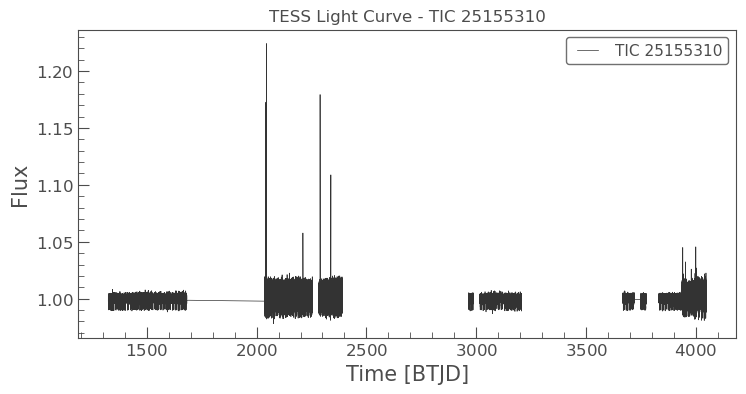

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk

# Define target star
target = "TIC 25155310"

# Search for TESS observations
search_result = lk.search_lightcurve(
    target,
    mission="TESS",
    author="SPOC"
)

# Show available observations
print(search_result)

# Download all available SPOC sectors
lc_collection = search_result.download_all()

# Combine all sectors
lc = lc_collection.stitch()

# Plot raw light curve
lc.plot()

plt.title(f"TESS Light Curve - {target}")
plt.xlabel("Time [BTJD]")
plt.ylabel("Flux")
plt.show()

## Analyis
The downloaded TESS light curve for TIC 25155310 shows the stellar flux measured over several observing sectors. The flux values are generally concentrated around a normalized value of approximately 1.0, indicating relatively stable stellar brightness during most observations.

Several large gaps are visible in the time series. These gaps occur because TESS observes a given target only during specific sectors, so continuous observations over the entire time range are not available.

The light curve also contains several strong upward spikes, particularly around BTJD 2000–2350 and near BTJD 4000. These points are likely outliers or instrumental/systematic effects rather than planetary transit signals. A planetary transit is expected to produce a small decrease in flux rather than a large increase.

Therefore, the raw light curve should be cleaned before searching for transit signals. The next preprocessing steps should include removing invalid measurements and outliers, checking TESS quality flags, and normalizing or flattening the light curve. After preprocessing, the cleaned data can be searched for periodic decreases in stellar brightness that may indicate possible exoplanet transits.

# Part 2 - Data Cleaning

## Theory
Before searching for planetary transit signals, the raw photometric measurements must be cleaned to remove unreliable observations.

TESS observations may contain measurements affected by:

- spacecraft operations,
- detector anomalies,
- cosmic ray events,
- missing or corrupted values.

Removing these measurements improves the quality of the light curve and prevents artificial signals from being interpreted as possible planetary transits.

The cleaning process includes:

1. Removing measurements with invalid flux values.
2. Removing observations flagged as poor quality.
3. Selecting only reliable photometric measurements for further analysis.




--------------------------------------
DATA CLEANING SUMMARY
--------------------------------------
Initial measurements: 2537501
Removed missing/corrupted measurements: 364720
Removed measurements with poor quality flags: 50501
Final reliable measurements: 2122280
--------------------------------------


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


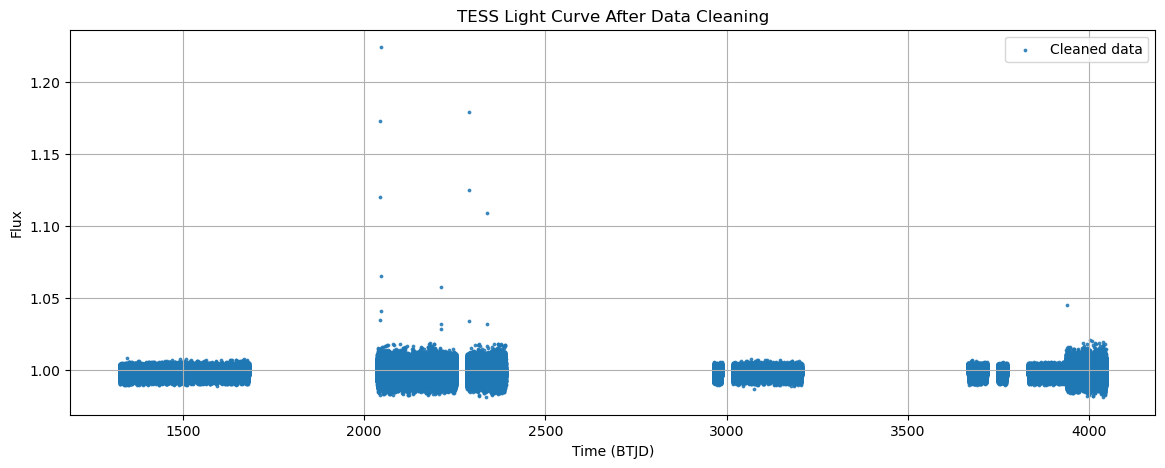

In [3]:

# Save the initial number of measurements
initial_points = len(lc)

# Keep only measurements with finite time and flux values

valid_mask = (
    np.isfinite(lc.time.value) &
    np.isfinite(lc.flux.value)
)

lc_clean = lc[valid_mask]

after_invalid_removal = len(lc_clean)


# TESS quality flag = 0 means that the measurement
# has no known data-quality problems.

if "quality" in lc_clean.colnames:
    lc_clean = lc_clean[lc_clean["quality"] == 0]


after_quality_filtering = len(lc_clean)


# ---------------------------------------------------------
# Data cleaning summary
# ---------------------------------------------------------

print("--------------------------------------")
print("DATA CLEANING SUMMARY")
print("--------------------------------------")

print("Initial measurements:", initial_points)

print(
    "Removed missing/corrupted measurements:",
    initial_points - after_invalid_removal
)

print(
    "Removed measurements with poor quality flags:",
    after_invalid_removal - after_quality_filtering
)

print("Final reliable measurements:", after_quality_filtering)

print("--------------------------------------")


# =========================================================
# Plot — Cleaned Light Curve
# =========================================================

plt.figure(figsize=(14, 5))

plt.scatter(
    lc_clean.time.value,
    lc_clean.flux.value,
    s=3,
    alpha=0.8,
    label="Cleaned data"
)

plt.title("TESS Light Curve After Data Cleaning")
plt.xlabel("Time (BTJD)")
plt.ylabel("Flux")
plt.legend()
plt.grid()

plt.show()

## Analysis 
The initial TESS dataset contained **2,537,501 photometric measurements**. During the cleaning process, **364,720 measurements** containing missing or corrupted values were removed. An additional **50,501 measurements** associated with non-zero TESS quality flags were excluded.

After both filtering stages, **2,122,280 measurements** remained for further analysis, corresponding to approximately **83.6% of the original dataset**.

The cleaned light curve contains several distinct observing intervals separated by large temporal gaps. These gaps reflect the availability of TESS observations across different observing sectors and are therefore preserved rather than interpolated.

Most measurements are concentrated close to a normalized flux level of approximately **1.0**, although several isolated high-flux points remain visible, particularly near BTJD ~2050–2350. These measurements passed the missing-value and quality-flag filters but are clear statistical outliers relative to the main flux distribution.

At this stage, they are intentionally retained because the purpose of the data-cleaning step is only to remove invalid measurements and observations flagged as unreliable by the TESS pipeline. Statistical outlier removal is performed separately in the following stage.

Overall, the cleaning procedure substantially reduced the number of unreliable measurements while preserving more than two million valid photometric observations for subsequent transit analysis.


# Part 3 - Outlier Removal

## Theory
The second preprocessing step focuses on the removal of outliers from the cleaned photometric data.

This stage includes:

- identifying measurements with abnormal flux values,
- removing isolated data points caused by random noise or remaining instrumental effects,
- excluding extreme variations that do not represent real astrophysical signals.

The goal is to improve the quality of the light curve by reducing noise while preserving genuine stellar variability.

--------------------------------------
OUTLIER REMOVAL SUMMARY
--------------------------------------
Measurements before outlier removal: 2122280
Detected positive outliers: 105
Measurements after outlier removal: 2122175
Percentage removed: 0.005 %
--------------------------------------


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


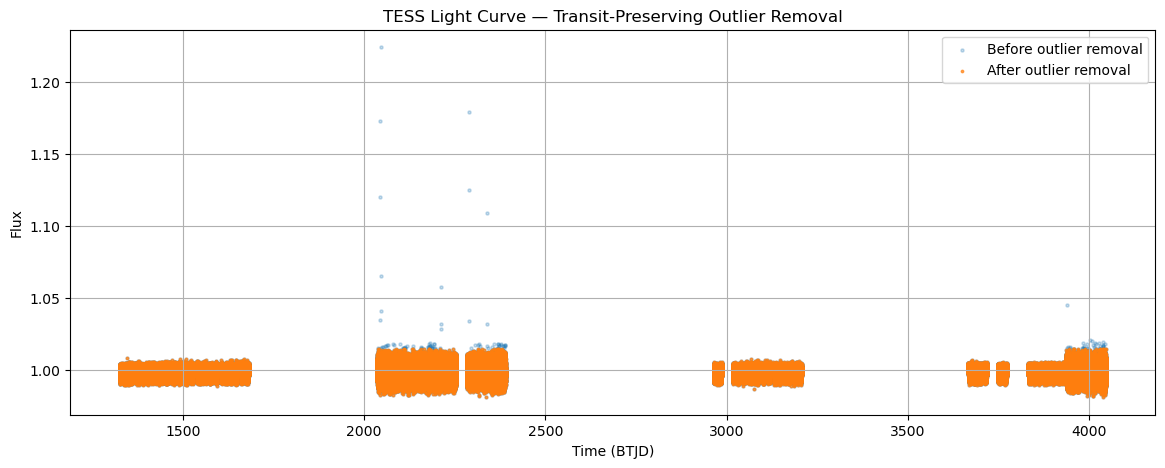

In [4]:
# =========================================================
# PART 3 — OUTLIER REMOVAL
# Transit-preserving sigma clipping
# =========================================================

import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Save original number of measurements
# ---------------------------------------------------------

before_outlier_removal = len(lc_clean)


# ---------------------------------------------------------
# Remove strong positive outliers only
#
# Negative deviations are preserved because planetary
# transits themselves appear as decreases in flux.
# ---------------------------------------------------------

lc_no_outliers, outlier_mask = lc_clean.remove_outliers(
    sigma_upper=5,
    sigma_lower=np.inf,
    return_mask=True
)


number_of_outliers = int(
    np.sum(outlier_mask)
)

after_outlier_removal = len(
    lc_no_outliers
)


percentage_removed = (
    number_of_outliers /
    before_outlier_removal
) * 100


# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

print("--------------------------------------")
print("OUTLIER REMOVAL SUMMARY")
print("--------------------------------------")

print(
    "Measurements before outlier removal:",
    before_outlier_removal
)

print(
    "Detected positive outliers:",
    number_of_outliers
)

print(
    "Measurements after outlier removal:",
    after_outlier_removal
)

print(
    "Percentage removed:",
    round(percentage_removed, 3),
    "%"
)

print("--------------------------------------")


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.scatter(
    lc_clean.time.value,
    lc_clean.flux.value,
    s=5,
    alpha=0.25,
    label="Before outlier removal"
)

plt.scatter(
    lc_no_outliers.time.value,
    lc_no_outliers.flux.value,
    s=3,
    alpha=0.7,
    label="After outlier removal"
)

plt.title(
    "TESS Light Curve — Transit-Preserving Outlier Removal"
)

plt.xlabel("Time (BTJD)")
plt.ylabel("Flux")

plt.legend()
plt.grid(True)

plt.show()


## Analysis

The outlier-removal stage was designed to eliminate extreme positive flux measurements while preserving possible transit signals.

Before outlier removal, the cleaned light curve contained **2,122,280 measurements**. A total of **105 strong positive outliers** were identified and removed, leaving **2,122,175 measurements** for subsequent analysis. This corresponds to only approximately **0.005% of the cleaned dataset**.

The very small fraction of removed measurements indicates that the previous data-cleaning stage had already preserved a largely stable photometric dataset while a limited number of extreme flux excursions remained.

Importantly, the clipping procedure was intentionally applied only to strong **positive flux deviations**. Planetary transits appear as temporary decreases in stellar brightness, meaning that aggressive symmetric sigma clipping could potentially remove genuine in-transit measurements. Negative deviations were therefore preserved at this stage to avoid suppressing possible transit signals before the period search.

The comparison between the light curves before and after outlier removal shows that the extreme high-flux measurements were removed while the main structure and observing intervals of the TESS light curve remained unchanged.

The resulting dataset therefore provides a cleaner photometric time series while maintaining potential transit-related decreases in flux for the subsequent detrending and BLS analysis.

# Part 4 - Detrending 

## Theory
Observed stellar flux contains both short-duration transit signals and longer-term variability. These slow variations can arise from stellar activity (such as star spots and flares), stellar rotation, instrumental systematics, and changes in observational conditions during data collection.

Detrending is a preprocessing technique used to remove these low-frequency trends from a stellar light curve while preserving short-duration signals such as planetary transits. By removing the baseline variability, the light curve becomes flatter and more suitable for transit detection methods such as the Box Least Squares (BLS) algorithm.

In practice, detrending isolates the high-frequency variations (potential transits) by filtering out long-term brightness changes that are not related to planetary events. This improves the detectability and accuracy of exoplanet transit searches.


In [ ]:
# =========================================================
# PART 4 — BINNING AND DETRENDING
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u


# ---------------------------------------------------------
# 1. Normalize light curve
# ---------------------------------------------------------

lc_normalized = lc_no_outliers.normalize()


# ---------------------------------------------------------
# 2. Bin to a uniform 10-minute cadence
#
# This ensures that the detrending window has approximately
# the same physical timescale across all TESS sectors.
# ---------------------------------------------------------

lc_uniform = lc_normalized.bin(
    time_bin_size=10 * u.minute
)

lc_uniform = lc_uniform.remove_nans()


# ---------------------------------------------------------
# 3. Remove long-term trends
#
# 289 bins × 10 min ≈ 48 hours.
# This is much longer than a ~3-hour planetary transit,
# helping to preserve the transit shape.
# ---------------------------------------------------------

window_length = 289

lc_detrended, trend_lc = lc_uniform.flatten(
    window_length=window_length,
    polyorder=2,
    break_tolerance=5,
    niters=3,
    sigma=5,
    return_trend=True
)


# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

print("--------------------------------------")
print("DETRENDING SUMMARY")
print("--------------------------------------")

print(
    "Uniform cadence:",
    "10 minutes"
)

print(
    "Detrending window:",
    window_length,
    "bins"
)

print(
    "Approximate window duration:",
    round(
        window_length * 10 / 60,
        2
    ),
    "hours"
)

print(
    "Measurements after binning:",
    len(lc_uniform)
)

print(
    "Measurements after detrending:",
    len(lc_detrended)
)

print("--------------------------------------")


# ---------------------------------------------------------
# Plot before and after detrending
# ---------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.scatter(
    lc_uniform.time.value,
    lc_uniform.flux.value,
    s=4,
    alpha=0.4,
    label="Before detrending"
)

plt.scatter(
    lc_detrended.time.value,
    lc_detrended.flux.value,
    s=4,
    alpha=0.7,
    label="After detrending"
)

plt.title(
    "TESS Light Curve — Before and After Detrending"
)

plt.xlabel("Time (BTJD)")
plt.ylabel("Normalized Flux")

plt.legend()
plt.grid(True)

plt.show()


## Analysis

Before detrending, the light curve was first binned to a uniform cadence of **10 minutes**. This reduced the dataset to **136,462 measurements** while preserving the temporal resolution required to resolve transit events lasting several hours.

Detrending was then performed using a window of **289 bins**, corresponding to approximately **48.17 hours**. This timescale was intentionally chosen to be substantially longer than the expected duration of a planetary transit. The objective was to remove slower variations in the stellar baseline without strongly suppressing short-duration transit signals.

The detrending procedure preserved all **136,462 binned measurements**, indicating that this stage modified the relative flux baseline rather than removing additional observations.

The resulting light curve is centered close to a normalized flux of **1.0** across the different TESS observing intervals. Comparison of the measurements before and after detrending shows that the overall structure of the observations is preserved while slow baseline variations are reduced.

Importantly, the recurrent downward flux features remain visible after detrending. Their preservation is essential because periodic decreases in stellar brightness are the signals subsequently examined by the Box Least Squares transit-search algorithm.

The detrended light curve therefore provides a more uniform photometric baseline for the period


# Part 6 - Planet Search
## Introduction
After cleaning the raw data and normalizing the light curve, the Box Least Squares (BLS) algorithm is applied to search for potential planetary transit signals. BLS is a widely used method for detecting transit-like features in photometric time-series data. The algorithm searches a range of orbital periods and transit durations by fitting repeating box-shaped models to the observed light curve. Periodic decreases in stellar brightness are then identified as potential transit candidates, which can be further investigated in subsequent candidate-identification and false-positive analyses.




In [ ]:
# =========================================================
# PART 6 — PLANET SEARCH
# Box Least Squares (BLS)
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

from astropy.timeseries import BoxLeastSquares


# ---------------------------------------------------------
# 1. Prepare detrended photometric data
# ---------------------------------------------------------

time_bls = np.asarray(
    lc_detrended.time.value,
    dtype=float
)

flux_bls = np.asarray(
    lc_detrended.flux.value,
    dtype=float
)


valid_mask = (
    np.isfinite(time_bls)
    &
    np.isfinite(flux_bls)
)


time_bls = time_bls[
    valid_mask
]

flux_bls = flux_bls[
    valid_mask
]


# ---------------------------------------------------------
# 2. Define BLS model
# ---------------------------------------------------------

bls = BoxLeastSquares(
    time_bls,
    flux_bls
)


# ---------------------------------------------------------
# 3. Define search parameters
# ---------------------------------------------------------

min_period = 0.5
max_period = 30.0


# Test transit durations from about
# 1 hour to 8 hours

durations = np.linspace(
    1 / 24,
    8 / 24,
    20
)


# ---------------------------------------------------------
# 4. Run automatically sampled BLS search
# ---------------------------------------------------------

bls_result = bls.autopower(
    durations,
    minimum_period=min_period,
    maximum_period=max_period,
    frequency_factor=1.0
)


# ---------------------------------------------------------
# 5. Identify strongest BLS peak
# ---------------------------------------------------------

best_index = np.nanargmax(
    bls_result.power
)


best_period = float(
    bls_result.period[
        best_index
    ]
)

best_duration = float(
    bls_result.duration[
        best_index
    ]
)

best_transit_time = float(
    bls_result.transit_time[
        best_index
    ]
)

best_depth = float(
    bls_result.depth[
        best_index
    ]
)

best_depth_snr = float(
    bls_result.depth_snr[
        best_index
    ]
)

best_power = float(
    bls_result.power[
        best_index
    ]
)


# ---------------------------------------------------------
# 6. Summary
# ---------------------------------------------------------

print("--------------------------------------")
print("BLS PLANET SEARCH SUMMARY")
print("--------------------------------------")

print(
    "Measurements used:",
    len(time_bls)
)

print(
    "Period search range:",
    min_period,
    "-",
    max_period,
    "days"
)

print(
    "Best period:",
    round(best_period, 6),
    "days"
)

print(
    "Best transit duration:",
    round(best_duration, 6),
    "days"
)

print(
    "Best transit duration:",
    round(best_duration * 24, 3),
    "hours"
)

print(
    "Best transit time:",
    round(best_transit_time, 6),
    "BTJD"
)

print(
    "Estimated transit depth:",
    round(best_depth, 6)
)

print(
    "Transit depth S/N:",
    round(best_depth_snr, 3)
)

print(
    "Maximum BLS power:",
    round(best_power, 6)
)

print("--------------------------------------")


# =========================================================
# GRAPH 1 — BLS PERIODOGRAM
# =========================================================

plt.figure(
    figsize=(14, 5)
)

plt.plot(
    np.asarray(
        bls_result.period,
        dtype=float
    ),
    np.asarray(
        bls_result.power,
        dtype=float
    )
)


plt.axvline(
    best_period,
    linestyle="--",
    label=(
        f"Strongest period = "
        f"{best_period:.6f} d"
    )
)


# Expected literature period can be added
# AFTER the blind search for comparison.

plt.title(
    "Box Least Squares Periodogram"
)

plt.xlabel(
    "Orbital Period (days)"
)

plt.ylabel(
    "BLS Power"
)

plt.legend()
plt.grid(True)

plt.show()


# =========================================================
# GRAPH 2 — PHASE-FOLDED LIGHT CURVE
# =========================================================

phase = (
    (
        time_bls -
        best_transit_time
    )
    /
    best_period
) % 1


phase[
    phase > 0.5
] -= 1


phase_order = np.argsort(
    phase
)


plt.figure(
    figsize=(14, 5)
)


plt.scatter(
    phase[
        phase_order
    ],
    flux_bls[
        phase_order
    ],
    s=5,
    alpha=0.4
)


plt.axvline(
    0,
    linestyle="--"
)


plt.title(
    "Phase-Folded Light Curve — "
    f"P = {best_period:.6f} days"
)

plt.xlabel(
    "Orbital Phase"
)

plt.ylabel(
    "Normalized Flux"
)

plt.grid(True)

plt.show()



## Analysis
The Box Least Squares search was performed over orbital periods between 0.5 and 30 days using 136,462 detrended photometric measurements. The strongest peak in the BLS periodogram occurs at a period of **6.578216 days**, with a maximum BLS power of **0.014631**. Several additional strong peaks are visible at longer periods, indicating the presence of harmonic or alias structures in the periodogram.

The phase-folded light curve at the strongest BLS period shows a clear and repeatable decrease in normalized flux. However, an important feature is that transit-like dips appear both around **phase 0** and near **phase ±0.5**. This indicates that the period of 6.578216 days may represent approximately twice the fundamental orbital period rather than the true orbital period itself. Dividing the strongest BLS period by two gives approximately **3.289108 days**, suggesting that the BLS algorithm may have selected the (2P) harmonic of the underlying transit signal.

The fitted transit depth is approximately **0.00202**, corresponding to a flux decrease of about **0.20%**. The preferred transit duration is **8.0 hours**, which is equal to the upper limit of the duration range tested in the BLS search. Because the best-fitting duration lies exactly at the search boundary, this value should be interpreted cautiously and investigated further using a wider or more finely sampled duration grid.

Although the periodogram contains a prominent peak, the reported transit-depth S/N of **0.167** is low and therefore the BLS peak alone is not sufficient to establish a reliable planetary detection. Further candidate screening is required to distinguish the fundamental orbital period from its harmonics and to test the consistency of individual transit events.

Overall, the BLS analysis identifies a strong periodic transit-like signal, but the phase-folded morphology suggests that **6.578216 days is likely a harmonic period**. The approximately **3.289-day signal should therefore be examined explicitly in the subsequent candidate-identification stage.**


# Part 7 - Candidate Identification

## Theory

After the Box Least Squares (BLS) search, the strongest periodic signals must be evaluated to determine which of them represent plausible transit candidates. A high BLS peak alone is not sufficient, because noise, stellar variability, instrumental effects, and harmonic periods may also produce strong signals.

According to the candidate-selection criteria defined for this project, each signal is evaluated based on four main properties:

### 1. Signal significance

The strength of each BLS peak is evaluated using a robust signal detection efficiency (SDE-like statistic):

$$
\mathrm{SDE} =
\frac{P_{\mathrm{BLS}}-\mathrm{median}(P_{\mathrm{BLS}})}
{1.4826\,\mathrm{MAD}(P_{\mathrm{BLS}})}
$$

Candidates with **SDE ≥ 6** are considered sufficiently significant for further analysis.

### 2. Periodicity

A planetary transit should repeat at approximately regular time intervals. Therefore, a candidate must contain at least **two observed transit events** in the available light curve.

### 3. Transit shape and harmonic screening

A plausible candidate should produce a localized decrease in flux when the light curve is phase-folded.

The strongest BLS peak does not always represent the true orbital period. Peaks may also occur at integer multiples or fractions of the fundamental period.

In Part 6, the strongest BLS signal was detected at **6.578216 days**. However, the phase-folded light curve shows transit-like events near both phase 0 and phase ±0.5. This suggests that 6.578216 days may represent approximately twice the fundamental orbital period.

Therefore, the **half-period hypothesis of approximately 3.289108 days** is also examined. Phase-folded light curves are compared to determine which period produces the more consistent transit sequence.

### 4. Consistency between individual transit events

Individual transit events belonging to the same candidate should have similar depths. Their consistency is evaluated using the relative depth scatter:

$$
S_{\mathrm{rel}} =
\frac{\sigma_{\mathrm{depth}}}
{|\overline{\mathrm{depth}}|}
$$

Candidates with a relative depth scatter of **0.50 or lower** are considered sufficiently consistent.

## Candidate Selection

The strongest independent local peaks in the BLS periodogram are identified and ranked by BLS power. Peaks separated by less than **0.05 days** are treated as part of the same periodogram feature.

For each candidate, the analysis examines:

- orbital period,
- BLS power and SDE,
- transit duration and depth,
- number of observed transit events,
- consistency of individual transit depths,
- and possible harmonic relationships.

Candidates satisfying the adopted significance, periodicity, transit-depth, and consistency criteria are retained for further false-positive analysis in the next stage.

In [ ]:
# =========================================================
# PART 7 — CANDIDATE IDENTIFICATION
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. Candidate-selection criteria
# ---------------------------------------------------------

N_CANDIDATES = 10

MIN_PERIOD_SEPARATION = 0.05       # days
SDE_THRESHOLD = 6.0
MIN_OBSERVED_TRANSITS = 2
MAX_RELATIVE_DEPTH_SCATTER = 0.50

HARMONIC_TOLERANCE = 0.02


# ---------------------------------------------------------
# 2. Prepare BLS results
# ---------------------------------------------------------

period_array = np.asarray(
    bls_result.period,
    dtype=float
)

power_array = np.asarray(
    bls_result.power,
    dtype=float
)

duration_array = np.asarray(
    bls_result.duration,
    dtype=float
)

transit_time_array = np.asarray(
    bls_result.transit_time,
    dtype=float
)

depth_array = np.asarray(
    bls_result.depth,
    dtype=float
)

depth_snr_array = np.asarray(
    bls_result.depth_snr,
    dtype=float
)


# ---------------------------------------------------------
# 3. Calculate robust SDE
# ---------------------------------------------------------

median_power = np.nanmedian(
    power_array
)

mad_power = np.nanmedian(
    np.abs(
        power_array - median_power
    )
)

robust_sigma = (
    1.4826 * mad_power
)


if np.isfinite(robust_sigma) and robust_sigma > 0:

    sde_array = (
        power_array - median_power
    ) / robust_sigma

else:

    sde_array = np.full_like(
        power_array,
        np.nan
    )


# ---------------------------------------------------------
# 4. Identify local BLS peaks
# ---------------------------------------------------------

local_peak_mask = np.zeros(
    len(power_array),
    dtype=bool
)

local_peak_mask[1:-1] = (
    (power_array[1:-1] > power_array[:-2])
    &
    (power_array[1:-1] >= power_array[2:])
)

local_peak_indices = np.where(
    local_peak_mask
)[0]


# Keep only finite peaks

finite_peak_mask = (
    np.isfinite(
        period_array[local_peak_indices]
    )
    &
    np.isfinite(
        power_array[local_peak_indices]
    )
)

local_peak_indices = local_peak_indices[
    finite_peak_mask
]


# ---------------------------------------------------------
# 5. Rank peaks by BLS power
# ---------------------------------------------------------

ranked_peak_indices = local_peak_indices[
    np.argsort(
        power_array[local_peak_indices]
    )[::-1]
]


# ---------------------------------------------------------
# 6. Select independent peaks
# ---------------------------------------------------------

selected_indices = []


for index in ranked_peak_indices:

    candidate_period = period_array[
        index
    ]


    if len(selected_indices) == 0:

        selected_indices.append(
            index
        )

    else:

        selected_periods = period_array[
            selected_indices
        ]

        period_difference = np.abs(
            selected_periods
            -
            candidate_period
        )


        if np.all(
            period_difference
            >= MIN_PERIOD_SEPARATION
        ):

            selected_indices.append(
                index
            )


    if len(selected_indices) >= N_CANDIDATES:

        break


# ---------------------------------------------------------
# 7. Prepare photometric data
# ---------------------------------------------------------

time = np.asarray(
    time_bls,
    dtype=float
)

flux = np.asarray(
    flux_bls,
    dtype=float
)


valid_mask = (
    np.isfinite(time)
    &
    np.isfinite(flux)
)

time = time[
    valid_mask
]

flux = flux[
    valid_mask
]


# ---------------------------------------------------------
# 8. Measure individual transit events
# ---------------------------------------------------------

def measure_transit_events(
    period,
    duration,
    transit_time
):

    transit_number = np.round(
        (time - transit_time)
        /
        period
    ).astype(int)


    predicted_transit_time = (
        transit_time
        +
        transit_number * period
    )


    distance = np.abs(
        time
        -
        predicted_transit_time
    )


    # Transit region

    in_transit = (
        distance <= duration / 2
    )


    # Local out-of-transit baseline

    out_of_transit = (
        (distance > duration)
        &
        (distance <= 3 * duration)
    )


    event_numbers = np.unique(
        transit_number[
            in_transit
        ]
    )


    event_depths = []


    for event in event_numbers:

        event_mask = (
            transit_number == event
        )


        event_in = (
            event_mask
            &
            in_transit
        )


        event_out = (
            event_mask
            &
            out_of_transit
        )


        # Require enough measurements
        # inside and outside the transit

        if (
            np.sum(event_in) >= 3
            and
            np.sum(event_out) >= 5
        ):

            flux_in = np.nanmedian(
                flux[
                    event_in
                ]
            )

            flux_out = np.nanmedian(
                flux[
                    event_out
                ]
            )


            transit_depth = (
                flux_out
                -
                flux_in
            )


            if np.isfinite(
                transit_depth
            ):

                event_depths.append(
                    transit_depth
                )


    return np.asarray(
        event_depths,
        dtype=float
    )


# ---------------------------------------------------------
# 9. Harmonic classification
# ---------------------------------------------------------

def classify_harmonic(
    period,
    reference_period
):

    ratio = (
        period /
        reference_period
    )


    if np.isclose(
        ratio,
        1.0,
        rtol=HARMONIC_TOLERANCE
    ):

        return "Reference peak"


    # Integer multiples

    for n in range(2, 10):

        if np.isclose(
            ratio,
            n,
            rtol=HARMONIC_TOLERANCE
        ):

            return f"{n} × reference"


    # Integer fractions

    for n in range(2, 10):

        if np.isclose(
            ratio,
            1 / n,
            rtol=HARMONIC_TOLERANCE
        ):

            return f"Reference / {n}"


    return "Independent"


# ---------------------------------------------------------
# 10. Strongest BLS period
# ---------------------------------------------------------

strongest_index = int(
    np.nanargmax(
        power_array
    )
)

strongest_period = float(
    period_array[
        strongest_index
    ]
)


# ---------------------------------------------------------
# 11. Evaluate candidates
# ---------------------------------------------------------

candidate_rows = []


for rank, index in enumerate(
    selected_indices,
    start=1
):

    period = float(
        period_array[index]
    )

    power = float(
        power_array[index]
    )

    sde = float(
        sde_array[index]
    )

    duration = float(
        duration_array[index]
    )

    transit_time = float(
        transit_time_array[index]
    )

    bls_depth = float(
        depth_array[index]
    )

    depth_snr = float(
        depth_snr_array[index]
    )


    # -----------------------------------------------------
    # Individual transit events
    # -----------------------------------------------------

    event_depths = measure_transit_events(
        period,
        duration,
        transit_time
    )


    observed_transits = len(
        event_depths
    )


    # -----------------------------------------------------
    # Median transit depth
    # -----------------------------------------------------

    if observed_transits > 0:

        median_event_depth = float(
            np.nanmedian(
                event_depths
            )
        )

    else:

        median_event_depth = np.nan


    # -----------------------------------------------------
    # Event-to-event consistency
    # -----------------------------------------------------

    if observed_transits >= 2:

        mean_depth = np.nanmean(
            event_depths
        )

        depth_std = np.nanstd(
            event_depths,
            ddof=1
        )


        if (
            np.isfinite(mean_depth)
            and
            np.abs(mean_depth) > 0
        ):

            relative_depth_scatter = float(
                depth_std
                /
                np.abs(mean_depth)
            )

        else:

            relative_depth_scatter = np.nan

    else:

        relative_depth_scatter = np.nan


    # -----------------------------------------------------
    # Harmonic relationship
    # -----------------------------------------------------

    harmonic_relation = classify_harmonic(
        period,
        strongest_period
    )


    # -----------------------------------------------------
    # Apply selection criteria
    # -----------------------------------------------------

    significance_pass = (
        np.isfinite(sde)
        and
        sde >= SDE_THRESHOLD
    )


    periodicity_pass = (
        observed_transits
        >= MIN_OBSERVED_TRANSITS
    )


    positive_depth_pass = (
        np.isfinite(median_event_depth)
        and
        median_event_depth > 0
    )


    consistency_pass = (
        np.isfinite(relative_depth_scatter)
        and
        relative_depth_scatter
        <= MAX_RELATIVE_DEPTH_SCATTER
    )


    all_pass = (
        significance_pass
        and
        periodicity_pass
        and
        positive_depth_pass
        and
        consistency_pass
    )


    candidate_status = (
        "PASS"
        if all_pass
        else "REJECT"
    )


    # -----------------------------------------------------
    # Store candidate
    # -----------------------------------------------------

    candidate_rows.append(
        {
            "Rank": rank,
            "Period (days)": period,
            "BLS power": power,
            "SDE": sde,
            "Duration (hours)": duration * 24,
            "Transit Time (BTJD)": transit_time,
            "BLS depth": bls_depth,
            "Depth SNR": depth_snr,
            "Observed transits": observed_transits,
            "Median event depth": median_event_depth,
            "Relative depth scatter": relative_depth_scatter,
            "Period / strongest": (
                period /
                strongest_period
            ),
            "Harmonic relation": harmonic_relation,
            "Significance pass": significance_pass,
            "Periodicity pass": periodicity_pass,
            "Positive depth pass": positive_depth_pass,
            "Consistency pass": consistency_pass,
            "Candidate status": candidate_status
        }
    )


# ---------------------------------------------------------
# 12. Create candidate table
# ---------------------------------------------------------

candidates_df = pd.DataFrame(
    candidate_rows
)


# ---------------------------------------------------------
# 13. Display candidate results
# ---------------------------------------------------------

display_columns = [
    "Rank",
    "Period (days)",
    "BLS power",
    "SDE",
    "Duration (hours)",
    "Observed transits",
    "Median event depth",
    "Relative depth scatter",
    "Harmonic relation",
    "Candidate status"
]


print(
    "----------------------------------------------------------"
)

print(
    "PART 7 — CANDIDATE IDENTIFICATION"
)

print(
    "----------------------------------------------------------"
)

print(
    f"Strongest BLS period: "
    f"{strongest_period:.6f} days"
)

print(
    f"Half-period hypothesis: "
    f"{strongest_period / 2:.6f} days"
)

print(
    "----------------------------------------------------------"
)


print(
    candidates_df[
        display_columns
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


print(
    "----------------------------------------------------------"
)

print(
    "Candidates passing all criteria:",
    np.sum(
        candidates_df[
            "Candidate status"
        ] == "PASS"
    )
)

print(
    "----------------------------------------------------------"
)


# ---------------------------------------------------------
# 14. Compare strongest period and half-period
# ---------------------------------------------------------

periods_to_compare = [
    strongest_period,
    strongest_period / 2
]

plot_titles = [
    "Strongest BLS Period",
    "Half-Period Hypothesis"
]


for test_period, plot_title in zip(
    periods_to_compare,
    plot_titles
):

    # Find BLS solution closest to tested period

    nearest_index = int(
        np.nanargmin(
            np.abs(
                period_array
                -
                test_period
            )
        )
    )


    test_transit_time = float(
        transit_time_array[
            nearest_index
        ]
    )


    # Calculate orbital phase

    phase = (
        (
            time
            -
            test_transit_time
            +
            0.5 * test_period
        )
        %
        test_period
    ) / test_period - 0.5


    phase_order = np.argsort(
        phase
    )


    # -----------------------------------------------------
    # Plot phase-folded light curve
    # -----------------------------------------------------

    plt.figure(
        figsize=(11, 5)
    )

    plt.scatter(
        phase[
            phase_order
        ],
        flux[
            phase_order
        ],
        s=4,
        alpha=0.25
    )

    plt.axvline(
        0,
        linestyle="--",
        label="Predicted transit"
    )

    plt.xlabel(
        "Orbital Phase"
    )

    plt.ylabel(
        "Normalized Flux"
    )

    plt.title(
        f"{plot_title}\n"
        f"P = {test_period:.6f} days"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

## Analysis

The candidate-identification stage produced ten independent BLS peaks. Three signals satisfied all adopted numerical screening criteria, while the remaining seven were rejected mainly because of poor consistency between individual transit depths.

The strongest BLS signal occurs at **6.578216 days**, with an SDE of **568.26**. Despite its very high significance, this candidate was rejected because its relative depth scatter is **1.584**, substantially above the adopted limit of 0.50. This indicates that the individual events are not sufficiently consistent when interpreted using this period.

The phase-folded light curve provides an important explanation. At **6.578216 days**, transit-like decreases appear around both phase 0 and phase ±0.5. This suggests that the strongest BLS period is likely a harmonic rather than the fundamental orbital period.

When the light curve is instead folded at half of this period, **3.289108 days**, the two groups of transit events overlap into a single concentrated transit feature around phase 0. This provides strong evidence that approximately **3.289 days is the more plausible fundamental orbital period**, while 6.578216 days represents approximately twice this period.

Three periods formally passed all numerical screening criteria:

- **29.598720 days** — SDE = 386.67, relative depth scatter = 0.199;
- **19.731946 days** — SDE = 361.82, relative depth scatter = 0.207;
- **26.311762 days** — SDE = 229.67, relative depth scatter = 0.488.

These signals should not yet be interpreted as three independent planetary candidates. In particular, the periods near **19.73 days** and **26.31 days** are approximately integer multiples of the strongest 6.578-day BLS period and may therefore belong to the same harmonic family.

The remaining signals were rejected mainly because their individual transit depths were inconsistent. For example, the **1.644829-day** signal has a high SDE of 120.57 but a relative depth scatter of **4.33**, demonstrating that a strong BLS peak alone is not sufficient to identify a reliable transit candidate.

Overall, the combination of BLS significance, event-to-event consistency, and phase-folded morphology indicates that several strong peaks are likely harmonic or alias structures. Most importantly, comparison of the strongest BLS period with its half-period hypothesis supports a fundamental transit period near **3.289 days**.

The approximately **3.289-day signal** should therefore be examined explicitly in the subsequent false-positive analysis.

# Part 8 - Transit Validation

## Introduction

After the candidate-identification stage, the surviving transit-like signals must be evaluated to determine whether they are consistent with planetary transits or can be explained by alternative astrophysical or systematic effects. A significant BLS signal alone is not sufficient to establish the planetary nature of a candidate.

Transit validation therefore examines the properties of each surviving candidate using a series of diagnostic tests designed to identify potential false-positive scenarios.

The validation process includes:

- **Odd–even transit comparison** – the depths of alternating transit events are compared. Significant differences between odd and even events may indicate an eclipsing binary rather than a planetary transit.

- **Secondary eclipse search** – the phase-folded light curve is examined near orbital phase 0.5 for an additional decrease in flux. A significant secondary eclipse may indicate the presence of an eclipsing stellar companion.

- **Harmonic and alias analysis** – candidate periods are compared to determine whether multiple signals represent independent periodicities or integer multiples and fractions of the same underlying signal.

- **Transit-shape assessment** – the morphology of the phase-folded transit is examined to determine whether the signal is compatible with a transit-like event. Strongly V-shaped or otherwise unusual features may indicate an eclipsing binary or another non-planetary source.

- **Transit-depth consistency and plausibility** – the measured depth and its stability across individual events are examined to assess whether the signal remains physically and observationally consistent.

Candidates that successfully pass these validation tests are considered stronger **validated transit candidates**. However, transit validation based solely on TESS photometry does not constitute definitive planetary confirmation. The purpose of this stage is to reject likely false positives and identify the most reliable signals for subsequent interpretation and comparison with known planetary systems.

In [ ]:
# =========================================================
# PART 8 — TRANSIT VALIDATION
# Odd–Even Test, Secondary Eclipse Search,
# Harmonic Analysis, Transit Shape,
# Transit-Depth Consistency
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. Validation settings
# ---------------------------------------------------------

ODD_EVEN_TOLERANCE = 0.30

SECONDARY_DEPTH_RATIO_LIMIT = 0.50

V_SHAPE_LIMIT = 0.50

MAX_RELATIVE_DEPTH_SCATTER = 0.50

HARMONIC_TOLERANCE = 0.02


# ---------------------------------------------------------
# 2. Define the primary period from Part 7
# ---------------------------------------------------------

# Part 7 showed that the strongest BLS period
# contains two transit sequences per folded cycle.
# Therefore, its half-period is tested as the
# fundamental orbital period.

primary_period = (
    strongest_period / 2
)


# Find the nearest BLS solution to the
# half-period hypothesis

primary_index = int(
    np.nanargmin(
        np.abs(
            period_array - primary_period
        )
    )
)


primary_period = float(
    period_array[
        primary_index
    ]
)

primary_duration = float(
    duration_array[
        primary_index
    ]
)

primary_transit_time = float(
    transit_time_array[
        primary_index
    ]
)

primary_sde = float(
    sde_array[
        primary_index
    ]
)


# ---------------------------------------------------------
# 3. Select periods for validation
# ---------------------------------------------------------

# Include:
# - the half-period hypothesis identified in Part 7
# - all candidates that passed Part 7

validation_rows = [
    {
        "Rank": 0,
        "Period (days)": primary_period,
        "SDE": primary_sde,
        "Duration (days)": primary_duration,
        "Transit Time (BTJD)": primary_transit_time,
        "Source": "Primary half-period hypothesis"
    }
]


passed_candidates = candidates_df[
    candidates_df[
        "Candidate status"
    ] == "PASS"
].copy()


for _, row in passed_candidates.iterrows():

    candidate_period = float(
        row[
            "Period (days)"
        ]
    )


    # Find corresponding BLS solution

    nearest_index = int(
        np.nanargmin(
            np.abs(
                period_array
                -
                candidate_period
            )
        )
    )


    validation_rows.append(
        {
            "Rank":
                int(
                    row["Rank"]
                ),

            "Period (days)":
                candidate_period,

            "SDE":
                float(
                    row["SDE"]
                ),

            "Duration (days)":
                float(
                    duration_array[
                        nearest_index
                    ]
                ),

            "Transit Time (BTJD)":
                float(
                    transit_time_array[
                        nearest_index
                    ]
                ),

            "Source":
                "Passed Part 7"
        }
    )


validation_candidates = pd.DataFrame(
    validation_rows
)


# ---------------------------------------------------------
# 4. Prepare photometric data
# ---------------------------------------------------------

time = np.asarray(
    time_bls,
    dtype=float
)

flux = np.asarray(
    flux_bls,
    dtype=float
)


valid_mask = (
    np.isfinite(time)
    &
    np.isfinite(flux)
)


time = time[
    valid_mask
]

flux = flux[
    valid_mask
]


# ---------------------------------------------------------
# 5. Validation function
# ---------------------------------------------------------

def validate_transit(
    period,
    duration,
    transit_time
):

    # =====================================================
    # PHASE
    # =====================================================

    phase = (
        (time - transit_time)
        /
        period
    ) % 1


    phase_centered = phase.copy()

    phase_centered[
        phase_centered > 0.5
    ] -= 1


    transit_phase_width = (
        duration / period
    )


    # =====================================================
    # A. IDENTIFY INDIVIDUAL TRANSIT EVENTS
    # =====================================================

    transit_number = np.round(
        (time - transit_time)
        /
        period
    ).astype(int)


    expected_transit_time = (
        transit_time
        +
        transit_number * period
    )


    distance_to_transit = np.abs(
        time
        -
        expected_transit_time
    )


    in_transit = (
        distance_to_transit
        <= duration / 2
    )


    # Local baseline

    local_out = (
        (distance_to_transit > duration)
        &
        (distance_to_transit <= 3 * duration)
    )


    events = np.unique(
        transit_number[
            in_transit
        ]
    )


    event_depths = []
    event_numbers = []


    for event in events:

        event_mask = (
            transit_number == event
        )

        event_in = (
            event_mask
            &
            in_transit
        )

        event_out = (
            event_mask
            &
            local_out
        )


        if (
            np.sum(event_in) >= 3
            and
            np.sum(event_out) >= 5
        ):

            in_flux = np.nanmedian(
                flux[
                    event_in
                ]
            )

            out_flux = np.nanmedian(
                flux[
                    event_out
                ]
            )


            depth = (
                out_flux
                -
                in_flux
            )


            # Keep every finite event.
            # Negative measurements are not removed,
            # because doing so would bias the depth
            # distribution.

            if np.isfinite(depth):

                event_depths.append(
                    depth
                )

                event_numbers.append(
                    event
                )


    event_depths = np.asarray(
        event_depths,
        dtype=float
    )

    event_numbers = np.asarray(
        event_numbers,
        dtype=int
    )


    # =====================================================
    # B. ODD–EVEN TRANSIT COMPARISON
    # =====================================================

    odd_depths = event_depths[
        event_numbers % 2 != 0
    ]

    even_depths = event_depths[
        event_numbers % 2 == 0
    ]


    odd_depth = (
        np.nanmedian(
            odd_depths
        )
        if len(odd_depths) > 0
        else np.nan
    )


    even_depth = (
        np.nanmedian(
            even_depths
        )
        if len(even_depths) > 0
        else np.nan
    )


    mean_odd_even_depth = np.nanmean(
        [
            odd_depth,
            even_depth
        ]
    )


    if (
        np.isfinite(odd_depth)
        and
        np.isfinite(even_depth)
        and
        np.isfinite(mean_odd_even_depth)
        and
        mean_odd_even_depth > 0
    ):

        odd_even_difference = (
            abs(
                odd_depth
                -
                even_depth
            )
            /
            mean_odd_even_depth
        )

    else:

        odd_even_difference = np.nan


    odd_even_pass = bool(
        np.isfinite(
            odd_even_difference
        )
        and
        odd_even_difference
        <= ODD_EVEN_TOLERANCE
    )


    # =====================================================
    # C. TRANSIT-DEPTH CONSISTENCY
    # =====================================================

    number_of_events = len(
        event_depths
    )


    if number_of_events > 0:

        median_event_depth = np.nanmedian(
            event_depths
        )

    else:

        median_event_depth = np.nan


    if number_of_events >= 2:

        mean_event_depth = np.nanmean(
            event_depths
        )

        event_depth_std = np.nanstd(
            event_depths,
            ddof=1
        )


        if (
            np.isfinite(mean_event_depth)
            and
            abs(mean_event_depth) > 0
        ):

            relative_depth_scatter = (
                event_depth_std
                /
                abs(mean_event_depth)
            )

        else:

            relative_depth_scatter = np.nan

    else:

        relative_depth_scatter = np.nan


    depth_consistency_pass = bool(
        np.isfinite(
            relative_depth_scatter
        )
        and
        relative_depth_scatter
        <= MAX_RELATIVE_DEPTH_SCATTER
    )


    depth_plausibility_pass = bool(
        np.isfinite(
            median_event_depth
        )
        and
        median_event_depth > 0
    )


    # =====================================================
    # D. SECONDARY ECLIPSE SEARCH
    # =====================================================

    primary_mask = (
        np.abs(
            phase_centered
        )
        <=
        transit_phase_width / 2
    )


    # Search around phase = 0.5

    secondary_distance = np.minimum(
        np.abs(
            phase - 0.5
        ),
        1
        -
        np.abs(
            phase - 0.5
        )
    )


    secondary_mask = (
        secondary_distance
        <=
        transit_phase_width / 2
    )


    # Baseline excluding primary and secondary

    baseline_mask = (
        ~primary_mask
        &
        ~secondary_mask
    )


    baseline_flux = (
        np.nanmedian(
            flux[
                baseline_mask
            ]
        )
        if np.any(
            baseline_mask
        )
        else np.nan
    )


    primary_flux = (
        np.nanmedian(
            flux[
                primary_mask
            ]
        )
        if np.any(
            primary_mask
        )
        else np.nan
    )


    secondary_flux = (
        np.nanmedian(
            flux[
                secondary_mask
            ]
        )
        if np.any(
            secondary_mask
        )
        else np.nan
    )


    primary_depth = (
        baseline_flux
        -
        primary_flux
    )


    secondary_depth = (
        baseline_flux
        -
        secondary_flux
    )


    if (
        np.isfinite(primary_depth)
        and
        primary_depth > 0
        and
        np.isfinite(secondary_depth)
    ):

        secondary_ratio = (
            max(
                secondary_depth,
                0
            )
            /
            primary_depth
        )

    else:

        secondary_ratio = np.nan


    secondary_pass = bool(
        np.isfinite(
            secondary_ratio
        )
        and
        secondary_ratio
        <
        SECONDARY_DEPTH_RATIO_LIMIT
    )


    # =====================================================
    # E. TRANSIT-SHAPE ASSESSMENT
    # =====================================================

    absolute_phase = np.abs(
        phase_centered
    )


    # Central part of transit

    central_mask = (
        absolute_phase
        <=
        transit_phase_width / 4
    )


    # Outer part of transit

    edge_mask = (
        (
            absolute_phase
            >
            transit_phase_width / 4
        )
        &
        (
            absolute_phase
            <=
            transit_phase_width / 2
        )
    )


    central_flux = (
        np.nanmedian(
            flux[
                central_mask
            ]
        )
        if np.any(
            central_mask
        )
        else np.nan
    )


    edge_flux = (
        np.nanmedian(
            flux[
                edge_mask
            ]
        )
        if np.any(
            edge_mask
        )
        else np.nan
    )


    central_depth = (
        baseline_flux
        -
        central_flux
    )


    edge_depth = (
        baseline_flux
        -
        edge_flux
    )


    if (
        np.isfinite(
            central_depth
        )
        and
        central_depth > 0
        and
        np.isfinite(
            edge_depth
        )
    ):

        v_shape_metric = (
            abs(
                central_depth
                -
                edge_depth
            )
            /
            central_depth
        )

    else:

        v_shape_metric = np.nan


    shape_pass = bool(
        np.isfinite(
            v_shape_metric
        )
        and
        v_shape_metric
        <= V_SHAPE_LIMIT
    )


    # =====================================================
    # RETURN
    # =====================================================

    return {

        "Observed events":
            number_of_events,

        "Median event depth":
            median_event_depth,

        "Relative depth scatter":
            relative_depth_scatter,

        "Depth consistency pass":
            depth_consistency_pass,

        "Depth plausibility pass":
            depth_plausibility_pass,

        "Odd depth":
            odd_depth,

        "Even depth":
            even_depth,

        "Odd-even difference":
            odd_even_difference,

        "Odd-even pass":
            odd_even_pass,

        "Primary depth":
            primary_depth,

        "Secondary depth":
            secondary_depth,

        "Secondary/Primary":
            secondary_ratio,

        "Secondary pass":
            secondary_pass,

        "V-shape metric":
            v_shape_metric,

        "Shape pass":
            shape_pass
    }


# ---------------------------------------------------------
# 6. Validate all selected periods
# ---------------------------------------------------------

validation_results = []


for _, row in validation_candidates.iterrows():

    period = float(
        row[
            "Period (days)"
        ]
    )

    duration = float(
        row[
            "Duration (days)"
        ]
    )

    transit_time = float(
        row[
            "Transit Time (BTJD)"
        ]
    )


    result = validate_transit(
        period=period,
        duration=duration,
        transit_time=transit_time
    )


    validation_results.append(
        {
            "Rank":
                int(
                    row[
                        "Rank"
                    ]
                ),

            "Period (days)":
                period,

            "SDE":
                float(
                    row[
                        "SDE"
                    ]
                ),

            "Duration (hours)":
                duration * 24,

            "Transit Time (BTJD)":
                transit_time,

            "Source":
                row[
                    "Source"
                ],

            **result
        }
    )


validation_df = pd.DataFrame(
    validation_results
)


# ---------------------------------------------------------
# 7. Harmonic and alias analysis
# ---------------------------------------------------------

def harmonic_relationship(
    period,
    fundamental_period
):

    ratio = (
        period /
        fundamental_period
    )


    # Fundamental signal

    if np.isclose(
        ratio,
        1.0,
        rtol=HARMONIC_TOLERANCE
    ):

        return (
            False,
            "Fundamental"
        )


    # Integer multiples

    for n in range(
        2,
        15
    ):

        if np.isclose(
            ratio,
            n,
            rtol=HARMONIC_TOLERANCE
        ):

            return (
                True,
                f"{n} × fundamental"
            )


    # Integer fractions

    for n in range(
        2,
        15
    ):

        if np.isclose(
            ratio,
            1 / n,
            rtol=HARMONIC_TOLERANCE
        ):

            return (
                True,
                f"Fundamental / {n}"
            )


    return (
        False,
        "Independent"
    )


harmonic_flags = []
harmonic_relations = []


for period in validation_df[
    "Period (days)"
]:

    flag, relation = harmonic_relationship(
        float(period),
        primary_period
    )

    harmonic_flags.append(
        flag
    )

    harmonic_relations.append(
        relation
    )


validation_df[
    "Possible harmonic"
] = harmonic_flags


validation_df[
    "Harmonic relation"
] = harmonic_relations


# ---------------------------------------------------------
# 8. Final validation status
# ---------------------------------------------------------

validation_df[
    "Validation status"
] = np.where(

    validation_df[
        "Odd-even pass"
    ]
    &
    validation_df[
        "Secondary pass"
    ]
    &
    validation_df[
        "Shape pass"
    ]
    &
    validation_df[
        "Depth consistency pass"
    ]
    &
    validation_df[
        "Depth plausibility pass"
    ]
    &
    (
        ~validation_df[
            "Possible harmonic"
        ]
    ),

    "PASSES PHOTOMETRIC VALIDATION",

    "REQUIRES CAUTION / POSSIBLE FALSE POSITIVE"
)


# ---------------------------------------------------------
# 9. Display results
# ---------------------------------------------------------

display_columns = [

    "Period (days)",
    "SDE",

    "Observed events",

    "Median event depth",
    "Relative depth scatter",

    "Odd depth",
    "Even depth",
    "Odd-even difference",

    "Secondary/Primary",

    "V-shape metric",

    "Harmonic relation",

    "Validation status"
]


print(
    "=" * 120
)

print(
    "PART 8 — TRANSIT VALIDATION RESULTS"
)

print(
    "=" * 120
)


print(
    validation_df[
        display_columns
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


print(
    "=" * 120
)


# ---------------------------------------------------------
# 10. Individual diagnostic summary
# ---------------------------------------------------------

for _, row in validation_df.iterrows():

    print(
        "\n---------------------------------------------"
    )

    print(
        f"Period: "
        f"{row['Period (days)']:.6f} days"
    )

    print(
        "---------------------------------------------"
    )

    print(
        "Odd-even test:",
        "PASS"
        if row["Odd-even pass"]
        else "FAIL"
    )

    print(
        "Secondary eclipse test:",
        "PASS"
        if row["Secondary pass"]
        else "FAIL"
    )

    print(
        "Transit-shape test:",
        "PASS"
        if row["Shape pass"]
        else "FAIL"
    )

    print(
        "Depth consistency:",
        "PASS"
        if row["Depth consistency pass"]
        else "FAIL"
    )

    print(
        "Depth plausibility:",
        "PASS"
        if row["Depth plausibility pass"]
        else "FAIL"
    )

    print(
        "Harmonic relation:",
        row["Harmonic relation"]
    )

    print(
        "FINAL:",
        row["Validation status"]
    )


# ---------------------------------------------------------
# 11. Phase-folded diagnostic plots
# ---------------------------------------------------------

for _, row in validation_df.iterrows():

    period = float(
        row[
            "Period (days)"
        ]
    )

    transit_time = float(
        row[
            "Transit Time (BTJD)"
        ]
    )


    phase = (
        (
            time
            -
            transit_time
            +
            0.5 * period
        )
        %
        period
    ) / period - 0.5


    order = np.argsort(
        phase
    )


    plt.figure(
        figsize=(11, 5)
    )


    plt.scatter(
        phase[
            order
        ],
        flux[
            order
        ],
        s=4,
        alpha=0.25
    )


    plt.axvline(
        0,
        linestyle="--",
        label="Primary transit"
    )


    plt.axvline(
        -0.5,
        linestyle=":",
        label="Secondary-eclipse phase"
    )


    plt.axvline(
        0.5,
        linestyle=":"
    )


    plt.xlabel(
        "Orbital Phase"
    )

    plt.ylabel(
        "Normalized Flux"
    )


    plt.title(
        f"Transit Validation — "
        f"P = {period:.6f} days\n"
        f"{row['Harmonic relation']}"
    )


    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

## Analysis

The transit-validation stage examined the fundamental-period hypothesis together with the three longer-period signals that passed the numerical screening in Part 7. None of the four tested periods passed all validation criteria, indicating that the detected signals require further caution before being interpreted as independent planetary candidates.

The fundamental-period hypothesis was evaluated at **3.291258 days**. Although the secondary-eclipse test was passed, several other diagnostics were not satisfied. The odd and even transit depths differ by approximately **62%**, which is above the adopted tolerance of 30%. The relative scatter of individual transit depths is also high at **2.34**, indicating substantial event-to-event variability. In addition, the V-shape metric of **0.579** exceeds the adopted limit of 0.50. Therefore, this period does not satisfy the full photometric-validation criteria in its current form.

The phase-folded light curve at approximately **3.29 days** also shows that the transit-like points are not concentrated exclusively at phase 0. Several groups of deep flux decreases appear at additional orbital phases. This suggests that the adopted period may still be slightly offset from the true fundamental period, or that residual harmonic structure remains present in the folded data.

The **29.598720-day** signal performs well in the individual photometric tests. It has highly consistent odd and even transit depths, a low relative depth scatter of **0.199**, no significant secondary eclipse, and a low V-shape metric of **0.151**. However, its period is approximately **9 times the proposed fundamental period**. The phase-folded light curve clearly shows repeated transit structures at several phases, rather than a single transit sequence. This strongly indicates that the 29.6-day peak is a harmonic of a shorter underlying signal rather than an independent planetary period.

The **19.731946-day** candidate is similarly identified as approximately **6 times the fundamental period**. Its individual transit depths are consistent and the odd-even comparison is satisfactory. However, the secondary-to-primary depth ratio is approximately **1.04**, meaning that the secondary feature is comparable in depth to the primary one. The V-shape metric of **0.541** also slightly exceeds the adopted threshold. Together with the clear harmonic relationship, these results argue against interpreting this signal as an independent planetary candidate.

The **26.311762-day** signal corresponds approximately to **8 times the fundamental period**. Although its odd-even comparison and depth consistency pass the adopted criteria, the secondary-eclipse ratio is high at approximately **0.93**, and the V-shape metric is **0.855**. These properties are inconsistent with the adopted planetary-transit screening criteria. Its integer relationship with the shorter period further supports a harmonic interpretation.

Overall, the longer-period signals at approximately **19.73, 26.31, and 29.60 days** are best interpreted as harmonic manifestations of a shorter periodic transit-like signal rather than independent transit candidates. The phase-folded morphology of these periods clearly shows multiple repeated transit features within a single folded cycle.

The approximately **3.29-day signal remains the most plausible fundamental periodicity**, but the current validation results show that its exact period and transit parameters still require refinement. In particular, the presence of several transit groups in the phase-folded light curve and the poor odd-even and depth-consistency results suggest that the currently adopted value of **3.291258 days** may not yet represent the optimal fundamental period.

Therefore, the next step should be to refine the orbital period around the approximately **3.289–3.291-day region** using a narrower and higher-resolution BLS search before performing the final transit validation and planetary characterization.

# Part 9 — Orbital Period Refinement

## Introduction

The previous stages identified a strong transit-like periodicity near **3.29 days**. The BLS search initially produced its strongest peak at approximately **6.58 days**, but the phase-folded light curve showed similar transit features at phase 0 and phase ±0.5. This indicated that the strongest BLS peak was likely a harmonic corresponding to approximately twice the fundamental period.

The half-period hypothesis near **3.29 days** produced a more plausible transit configuration and was therefore selected as the fundamental-period hypothesis for further investigation.

However, the transit-validation stage showed that the currently adopted period does not yet produce fully consistent individual transit events. In particular, the odd-even comparison, transit-depth consistency, and transit-shape tests were not all satisfied.

A small error in the orbital period can accumulate over a long observational baseline and cause individual transits to become misaligned when the light curve is phase-folded. This can broaden the transit feature and artificially reduce the apparent consistency of the signal.

Therefore, a high-resolution BLS search is performed over a narrow interval around the approximately **3.29-day** signal.

The refinement aims to obtain more precise estimates of:

- orbital period,
- transit duration,
- transit time,
- transit depth.

The refined solution is then examined using a new phase-folded light curve. A more accurate period should produce a better alignment of repeated transit events and a more concentrated transit feature around phase 0.

The refined parameters obtained in this stage will be used for the subsequent preliminary physical characterization of the candidate.


In [ ]:
# =========================================================
# PART 9 — ORBITAL PERIOD REFINEMENT
# High-resolution local BLS search
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

from astropy.timeseries import BoxLeastSquares


# ---------------------------------------------------------
# 1. Prepare photometric data
# ---------------------------------------------------------

time_refine = np.asarray(
    time_bls,
    dtype=float
)

flux_refine = np.asarray(
    flux_bls,
    dtype=float
)


valid_mask = (
    np.isfinite(time_refine)
    &
    np.isfinite(flux_refine)
)


time_refine = time_refine[
    valid_mask
]

flux_refine = flux_refine[
    valid_mask
]


# ---------------------------------------------------------
# 2. Define local BLS model
# ---------------------------------------------------------

bls_refine = BoxLeastSquares(
    time_refine,
    flux_refine
)


# ---------------------------------------------------------
# 3. Define high-resolution period grid
# ---------------------------------------------------------

# Part 7 and Part 8 indicate that the fundamental
# periodicity is located close to 3.29 days.

min_refined_period = 3.28
max_refined_period = 3.30


# Dense local period grid

refined_periods = np.linspace(
    min_refined_period,
    max_refined_period,
    40000
)


# ---------------------------------------------------------
# 4. Define transit-duration grid
# ---------------------------------------------------------

# Search transit durations between
# approximately 1 and 10 hours.

refined_durations = np.linspace(
    1 / 24,
    10 / 24,
    40
)


# ---------------------------------------------------------
# 5. Run high-resolution BLS search
# ---------------------------------------------------------

refined_result = bls_refine.power(
    refined_periods,
    refined_durations
)


# ---------------------------------------------------------
# 6. Identify best local BLS solution
# ---------------------------------------------------------

best_refined_index = int(
    np.nanargmax(
        refined_result.power
    )
)


refined_period = float(
    refined_result.period[
        best_refined_index
    ]
)

refined_duration = float(
    refined_result.duration[
        best_refined_index
    ]
)

refined_transit_time = float(
    refined_result.transit_time[
        best_refined_index
    ]
)

refined_depth = float(
    refined_result.depth[
        best_refined_index
    ]
)

refined_depth_snr = float(
    refined_result.depth_snr[
        best_refined_index
    ]
)

refined_power = float(
    refined_result.power[
        best_refined_index
    ]
)


# ---------------------------------------------------------
# 7. Calculate local robust SDE
# ---------------------------------------------------------

median_local_power = np.nanmedian(
    refined_result.power
)

mad_local_power = np.nanmedian(
    np.abs(
        refined_result.power
        -
        median_local_power
    )
)

local_robust_sigma = (
    1.4826 * mad_local_power
)


if (
    np.isfinite(local_robust_sigma)
    and
    local_robust_sigma > 0
):

    refined_sde = (
        refined_power
        -
        median_local_power
    ) / local_robust_sigma

else:

    refined_sde = np.nan


# ---------------------------------------------------------
# 8. Print refinement summary
# ---------------------------------------------------------

print(
    "----------------------------------------------------------"
)

print(
    "PART 9 — ORBITAL PERIOD REFINEMENT"
)

print(
    "----------------------------------------------------------"
)

print(
    f"Measurements used: "
    f"{len(time_refine)}"
)

print(
    f"Local search range: "
    f"{min_refined_period:.6f} - "
    f"{max_refined_period:.6f} days"
)

print(
    f"Refined orbital period: "
    f"{refined_period:.9f} days"
)

print(
    f"Best transit duration: "
    f"{refined_duration * 24:.3f} hours"
)

print(
    f"Best transit time: "
    f"{refined_transit_time:.6f} BTJD"
)

print(
    f"Estimated transit depth: "
    f"{refined_depth:.6f}"
)

print(
    f"Transit depth S/N: "
    f"{refined_depth_snr:.3f}"
)

print(
    f"Maximum local BLS power: "
    f"{refined_power:.6f}"
)

print(
    f"Local robust SDE: "
    f"{refined_sde:.3f}"
)

print(
    "----------------------------------------------------------"
)


# ---------------------------------------------------------
# 9. Plot high-resolution local BLS periodogram
# ---------------------------------------------------------

plt.figure(
    figsize=(11, 5)
)


plt.plot(
    refined_result.period,
    refined_result.power
)


plt.axvline(
    refined_period,
    linestyle="--",
    label=(
        f"Best period = "
        f"{refined_period:.9f} d"
    )
)


plt.xlabel(
    "Orbital Period (days)"
)

plt.ylabel(
    "BLS Power"
)

plt.title(
    "High-Resolution BLS Period Refinement"
)

plt.legend(
    loc="upper right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# 10. Calculate phase using refined ephemeris
# ---------------------------------------------------------

phase_refined = (
    (
        time_refine
        -
        refined_transit_time
        +
        0.5 * refined_period
    )
    %
    refined_period
) / refined_period - 0.5


phase_order = np.argsort(
    phase_refined
)


# ---------------------------------------------------------
# 11. Full phase-folded light curve
# ---------------------------------------------------------

plt.figure(
    figsize=(11, 5)
)


plt.scatter(
    phase_refined[
        phase_order
    ],
    flux_refine[
        phase_order
    ],
    s=4,
    alpha=0.25
)


plt.axvline(
    0,
    linestyle="--"
)


plt.xlabel(
    "Orbital Phase"
)

plt.ylabel(
    "Normalized Flux"
)

plt.title(
    "Phase-Folded Light Curve — "
    f"P = {refined_period:.9f} days"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# 12. Zoom around the predicted transit
# ---------------------------------------------------------

transit_phase_width = (
    refined_duration
    /
    refined_period
)


zoom_limit = (
    4 * transit_phase_width
)


zoom_mask = (
    np.abs(
        phase_refined
    )
    <=
    zoom_limit
)


plt.figure(
    figsize=(11, 5)
)


plt.scatter(
    phase_refined[
        zoom_mask
    ],
    flux_refine[
        zoom_mask
    ],
    s=6,
    alpha=0.30
)


plt.axvline(
    0,
    linestyle="--"
)


plt.xlabel(
    "Orbital Phase"
)

plt.ylabel(
    "Normalized Flux"
)

plt.title(
    "Refined Transit — Zoomed View"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# 13. Store refined parameters for Part 10
# ---------------------------------------------------------

final_period = refined_period

final_duration = refined_duration

final_transit_time = refined_transit_time

final_transit_depth = refined_depth

final_period_sde = refined_sde


print(
    "\nRefined parameters stored for Part 10:"
)

print(
    f"final_period = "
    f"{final_period:.9f} days"
)

print(
    f"final_duration = "
    f"{final_duration * 24:.3f} hours"
)

print(
    f"final_transit_time = "
    f"{final_transit_time:.6f} BTJD"
)

print(
    f"final_transit_depth = "
    f"{final_transit_depth:.6f}"
)

## Analysis

The high-resolution BLS search significantly improved the determination of the fundamental orbital period. Within the narrow search interval of **3.280–3.300 days**, a strong and well-defined BLS maximum was detected at **3.288784720 days**.

The refined signal has a maximum local BLS power of **0.092094** and a robust local SDE of **75.85**, indicating that the peak is strongly distinguished from the surrounding periodogram structure. The narrow and clearly defined maximum also supports a precise localization of the periodic signal within the investigated interval.

The refinement produced a best-fit transit duration of approximately **3.1 hours** and a transit depth of **0.005883**, corresponding to a decrease in normalized stellar flux of approximately **0.59%**. The best transit time was determined as **1327.522320 BTJD**.

Most importantly, the phase-folded light curve at the refined period shows a single, clearly concentrated transit feature around phase 0. The multiple separated transit groups visible when the light curve was folded using the less precise period in Part 8 are no longer present. This demonstrates that the previous inconsistencies were largely caused by an inaccurate orbital period rather than by several independent periodic signals.

The zoomed phase-folded light curve also reveals a well-defined transit morphology with a relatively flat central region and clearly visible ingress and egress. The repeated observations align closely after refinement, producing a substantially more coherent transit structure.

The refined period of **3.288784720 days** is also consistent with the harmonic interpretation developed in Parts 7 and 8. The original strongest BLS period near **6.578 days** corresponds approximately to twice the refined fundamental period, while several of the longer-period BLS peaks can be explained as higher-order harmonics of the same underlying periodic signal.

Overall, the local refinement strongly supports **3.288784720 days as the fundamental photometric period** of the detected transit-like signal. The substantial improvement in the phase-folded morphology confirms that precise period determination was essential for correctly aligning the individual transit events.

The refined parameters — particularly the orbital period of **3.288784720 days**, transit duration of approximately **3.1 hours**, and transit depth of **0.005883** — provide the appropriate photometric parameters for the preliminary **Planet Characterization** in Part 10.

# Part 10 — Transit Modeling and Monte Carlo Uncertainty Analysis

## Introduction

After refining the orbital period in Part 9, the transit signal can be described using a physical transit model rather than the box-shaped approximation used by the Box Least Squares algorithm.

In this stage, the **BATMAN** package is used to generate a physical model of a planet transiting its host star. The model accounts for the geometry of the transit and the effect of stellar limb darkening.

The refined orbital period and transit time obtained in Part 9 are used as the initial ephemeris. The model is then fitted to the phase-folded transit in order to estimate the most important transit parameters:

- planet-to-star radius ratio \(R_p/R_*\),
- scaled orbital distance \(a/R_*\),
- orbital inclination,
- transit timing,
- limb-darkening behaviour.

A circular orbit is assumed for this preliminary model.

The planet-to-star radius ratio determines the approximate transit depth and is one of the most important parameters for subsequent estimation of the planetary radius.

The scaled orbital distance and inclination control the transit duration and geometry, while the limb-darkening coefficients describe the decrease in stellar surface brightness toward the edge of the stellar disk.

### Monte Carlo Uncertainty Analysis

A single best-fit transit model does not provide information about the uncertainty of the fitted parameters.

Therefore, a Monte Carlo analysis is performed to estimate how strongly the model parameters depend on observational noise.

Synthetic realizations of the transit light curve are generated by adding random noise to the best-fit model. Each realization is then fitted again using the same transit model.

The distributions of the recovered parameters are used to estimate:

- median fitted values,
- standard deviations,
- approximate uncertainty intervals,
- stability of the fitted solution.

The final fitted parameters and their uncertainties provide a more realistic basis for the physical planet characterization performed in the next stage.



In [ ]:
# =========================================================
# PART 10 — TRANSIT MODELING AND MONTE CARLO ANALYSIS
# BATMAN physical transit model
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

import batman

from scipy.optimize import least_squares


# ---------------------------------------------------------
# 1. Prepare photometric data
# ---------------------------------------------------------

time_model = np.asarray(
    time_bls,
    dtype=float
)

flux_model = np.asarray(
    flux_bls,
    dtype=float
)


valid_mask = (
    np.isfinite(time_model)
    &
    np.isfinite(flux_model)
)


time_model = time_model[
    valid_mask
]

flux_model = flux_model[
    valid_mask
]


# ---------------------------------------------------------
# 2. Use refined ephemeris from Part 9
# ---------------------------------------------------------

model_period = float(
    final_period
)

model_t0 = float(
    final_transit_time
)


# ---------------------------------------------------------
# 3. Phase-fold the data
# ---------------------------------------------------------

phase_model = (
    (
        time_model
        -
        model_t0
        +
        0.5 * model_period
    )
    %
    model_period
) / model_period - 0.5


# ---------------------------------------------------------
# 4. Select data around the transit
# ---------------------------------------------------------

# Use a window wide enough to include
# the transit and surrounding baseline

phase_window = 0.08


transit_window_mask = (
    np.abs(
        phase_model
    )
    <=
    phase_window
)


phase_fit = phase_model[
    transit_window_mask
]

flux_fit = flux_model[
    transit_window_mask
]


# Convert phase to time relative to transit center

time_fit = (
    phase_fit
    *
    model_period
)


# ---------------------------------------------------------
# 5. Bin phase-folded data
# ---------------------------------------------------------

# Binning reduces computational cost and
# suppresses high-frequency scatter.

N_BINS = 250


bin_edges = np.linspace(
    np.min(time_fit),
    np.max(time_fit),
    N_BINS + 1
)


bin_centers = 0.5 * (
    bin_edges[:-1]
    +
    bin_edges[1:]
)


binned_flux = np.full(
    N_BINS,
    np.nan
)


binned_error = np.full(
    N_BINS,
    np.nan
)


for i in range(N_BINS):

    bin_mask = (
        (time_fit >= bin_edges[i])
        &
        (time_fit < bin_edges[i + 1])
    )


    if np.sum(bin_mask) >= 3:

        values = flux_fit[
            bin_mask
        ]

        binned_flux[i] = np.nanmedian(
            values
        )

        binned_error[i] = (
            np.nanstd(
                values
            )
            /
            np.sqrt(
                np.sum(bin_mask)
            )
        )


valid_bins = (
    np.isfinite(binned_flux)
    &
    np.isfinite(binned_error)
    &
    (binned_error > 0)
)


time_fit_binned = bin_centers[
    valid_bins
]

flux_fit_binned = binned_flux[
    valid_bins
]

error_fit_binned = binned_error[
    valid_bins
]


# ---------------------------------------------------------
# 6. BATMAN transit model
# ---------------------------------------------------------

def generate_batman_model(
    time_values,
    rp_rs,
    a_rs,
    inclination,
    t0_offset,
    u1,
    u2
):

    params = batman.TransitParams()

    params.t0 = (
        t0_offset
    )

    params.per = (
        model_period
    )

    params.rp = (
        rp_rs
    )

    params.a = (
        a_rs
    )

    params.inc = (
        inclination
    )

    params.ecc = 0.0

    params.w = 90.0

    params.limb_dark = (
        "quadratic"
    )

    params.u = [
        u1,
        u2
    ]


    transit_model = batman.TransitModel(
        params,
        time_values
    )


    model_flux = transit_model.light_curve(
        params
    )


    return model_flux


# ---------------------------------------------------------
# 7. Residual function
# ---------------------------------------------------------

def residual_function(
    parameter_vector,
    time_values,
    observed_flux,
    observed_error
):

    rp_rs = parameter_vector[0]

    a_rs = parameter_vector[1]

    inclination = parameter_vector[2]

    t0_offset = parameter_vector[3]

    u1 = parameter_vector[4]

    u2 = parameter_vector[5]


    model_flux = generate_batman_model(
        time_values,
        rp_rs,
        a_rs,
        inclination,
        t0_offset,
        u1,
        u2
    )


    residuals = (
        observed_flux
        -
        model_flux
    ) / observed_error


    return residuals


# ---------------------------------------------------------
# 8. Initial parameter estimates
# ---------------------------------------------------------

initial_rp_rs = np.sqrt(
    final_transit_depth
)


initial_parameters = np.array(
    [
        initial_rp_rs,   # Rp / R*
        7.0,             # a / R*
        87.0,            # inclination
        0.0,             # transit-center offset
        0.35,            # limb-darkening u1
        0.25             # limb-darkening u2
    ],
    dtype=float
)


# ---------------------------------------------------------
# 9. Parameter bounds
# ---------------------------------------------------------

lower_bounds = np.array(
    [
        0.01,      # Rp / R*
        2.0,       # a / R*
        75.0,      # inclination
        -0.05,     # t0 offset
        0.0,       # u1
        0.0        # u2
    ]
)


upper_bounds = np.array(
    [
        0.20,      # Rp / R*
        30.0,      # a / R*
        90.0,      # inclination
        0.05,      # t0 offset
        1.0,       # u1
        1.0        # u2
    ]
)


# ---------------------------------------------------------
# 10. Fit BATMAN model
# ---------------------------------------------------------

fit_result = least_squares(
    residual_function,
    initial_parameters,
    bounds=(
        lower_bounds,
        upper_bounds
    ),
    args=(
        time_fit_binned,
        flux_fit_binned,
        error_fit_binned
    )
)


best_parameters = fit_result.x


best_rp_rs = float(
    best_parameters[0]
)

best_a_rs = float(
    best_parameters[1]
)

best_inclination = float(
    best_parameters[2]
)

best_t0_offset = float(
    best_parameters[3]
)

best_u1 = float(
    best_parameters[4]
)

best_u2 = float(
    best_parameters[5]
)


# ---------------------------------------------------------
# 11. Generate best-fit model
# ---------------------------------------------------------

model_time_dense = np.linspace(
    np.min(time_fit_binned),
    np.max(time_fit_binned),
    2000
)


best_model_flux = generate_batman_model(
    model_time_dense,
    best_rp_rs,
    best_a_rs,
    best_inclination,
    best_t0_offset,
    best_u1,
    best_u2
)


# ---------------------------------------------------------
# 12. Estimate residual scatter
# ---------------------------------------------------------

model_flux_at_data = generate_batman_model(
    time_fit_binned,
    best_rp_rs,
    best_a_rs,
    best_inclination,
    best_t0_offset,
    best_u1,
    best_u2
)


fit_residuals = (
    flux_fit_binned
    -
    model_flux_at_data
)


residual_scatter = np.nanstd(
    fit_residuals
)


# ---------------------------------------------------------
# 13. Monte Carlo uncertainty analysis
# ---------------------------------------------------------

N_MONTE_CARLO = 300


rng = np.random.default_rng(
    42
)


mc_parameters = []


for iteration in range(
    N_MONTE_CARLO
):

    synthetic_flux = (
        model_flux_at_data
        +
        rng.normal(
            0,
            error_fit_binned
        )
    )


    try:

        mc_fit = least_squares(
            residual_function,
            best_parameters,
            bounds=(
                lower_bounds,
                upper_bounds
            ),
            args=(
                time_fit_binned,
                synthetic_flux,
                error_fit_binned
            ),
            max_nfev=2000
        )


        if mc_fit.success:

            mc_parameters.append(
                mc_fit.x
            )

    except Exception:

        pass


mc_parameters = np.asarray(
    mc_parameters,
    dtype=float
)


# ---------------------------------------------------------
# 14. Monte Carlo statistics
# ---------------------------------------------------------

if len(mc_parameters) == 0:

    raise RuntimeError(
        "No successful Monte Carlo fits."
    )


parameter_names = [
    "Rp/R*",
    "a/R*",
    "Inclination",
    "t0 offset",
    "u1",
    "u2"
]


mc_median = np.nanmedian(
    mc_parameters,
    axis=0
)


mc_std = np.nanstd(
    mc_parameters,
    axis=0,
    ddof=1
)


mc_lower = np.nanpercentile(
    mc_parameters,
    16,
    axis=0
)


mc_upper = np.nanpercentile(
    mc_parameters,
    84,
    axis=0
)


# ---------------------------------------------------------
# 15. Print BATMAN fit summary
# ---------------------------------------------------------

print(
    "----------------------------------------------------------"
)

print(
    "PART 10 — BATMAN TRANSIT MODEL"
)

print(
    "----------------------------------------------------------"
)

print(
    f"Refined period fixed at: "
    f"{model_period:.9f} days"
)

print(
    f"Rp/R*: "
    f"{best_rp_rs:.5f}"
)

print(
    f"a/R*: "
    f"{best_a_rs:.3f}"
)

print(
    f"Inclination: "
    f"{best_inclination:.3f} deg"
)

print(
    f"Transit-center offset: "
    f"{best_t0_offset:.6f} days"
)

print(
    f"Limb-darkening u1: "
    f"{best_u1:.3f}"
)

print(
    f"Limb-darkening u2: "
    f"{best_u2:.3f}"
)

print(
    f"Residual scatter: "
    f"{residual_scatter:.6f}"
)

print(
    "----------------------------------------------------------"
)


# ---------------------------------------------------------
# 16. Print Monte Carlo summary
# ---------------------------------------------------------

print(
    "\n=========================================================="
)

print(
    "MONTE CARLO PARAMETER UNCERTAINTIES"
)

print(
    "=========================================================="
)

print(
    f"Successful realizations: "
    f"{len(mc_parameters)} / "
    f"{N_MONTE_CARLO}"
)

print(
    "----------------------------------------------------------"
)


for i, name in enumerate(
    parameter_names
):

    print(
        f"{name:15s}: "
        f"{mc_median[i]:.6f} "
        f"+{mc_upper[i] - mc_median[i]:.6f} "
        f"-{mc_median[i] - mc_lower[i]:.6f}"
    )


print(
    "=========================================================="
)


# ---------------------------------------------------------
# 17. Plot best-fit BATMAN model
# ---------------------------------------------------------

plt.figure(
    figsize=(11, 5)
)


plt.errorbar(
    time_fit_binned * 24,
    flux_fit_binned,
    yerr=error_fit_binned,
    fmt=".",
    alpha=0.6,
    label="Binned TESS data"
)


plt.plot(
    model_time_dense * 24,
    best_model_flux,
    linewidth=2,
    label="Best-fit BATMAN model"
)


plt.xlabel(
    "Time from Transit Center (hours)"
)

plt.ylabel(
    "Normalized Flux"
)

plt.title(
    "BATMAN Physical Transit Model"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# 18. Store parameters for Part 11
# ---------------------------------------------------------

final_rp_rs = float(
    mc_median[0]
)

final_rp_rs_uncertainty = float(
    mc_std[0]
)


final_a_rs = float(
    mc_median[1]
)

final_a_rs_uncertainty = float(
    mc_std[1]
)


final_inclination = float(
    mc_median[2]
)

final_inclination_uncertainty = float(
    mc_std[2]
)


final_model_t0 = (
    model_t0
    +
    float(
        mc_median[3]
    )
)


print(
    "\nParameters stored for Part 11."
    
)

## Analysis

The physical transit model provides a very good match to the phase-folded TESS light curve. The fitted BATMAN model reproduces the transit depth, ingress, flat central region, and egress with only small residual differences.

The refined orbital period was fixed at **3.288784720 days**, while the transit geometry was fitted using BATMAN.

The best-fit planet-to-star radius ratio is:

$$
R_p/R_* \approx 0.0763
$$

The Monte Carlo analysis gives a median value of **0.076195**, with an uncertainty of approximately **±0.0005**. This indicates that the radius ratio is well constrained by the transit data.

The fitted scaled orbital distance is:

$$
a/R_* \approx 7.42
$$

with an uncertainty of approximately **±0.12**.

The orbital inclination is approximately **87.28°**, with an uncertainty of about **±0.41°**. This high inclination is consistent with the geometry required for a transiting planetary system.

The fitted transit-center offset is only about **−0.00095 days**, corresponding to approximately **−1.4 minutes** relative to the ephemeris obtained in Part 9. This small correction confirms that the refined transit timing was already very close to the optimal model solution.

The fitted quadratic limb-darkening coefficients are approximately:

- **u1 = 0.256**
- **u2 = 0.408**

with larger uncertainties than the main geometric transit parameters. This is expected because limb-darkening coefficients are generally less strongly constrained by the photometric transit shape than the transit depth and timing.

The residual scatter of the best-fit model is approximately **0.000105**, showing that the BATMAN model describes the binned transit light curve very closely.

The Monte Carlo analysis was successful for **all 300 realizations**. The recovered parameter distributions are narrow, particularly for the planet-to-star radius ratio, scaled orbital distance, inclination, and transit timing. This demonstrates that the fitted transit solution is stable against the photometric noise represented in the Monte Carlo simulations.

Overall, the BATMAN fit strongly supports a coherent transit geometry for the detected **3.288784720-day** signal. The physical transit model provides substantially more detailed information than the original BLS box model and confirms that the observed light-curve morphology is consistent with a transiting object.

The fitted value of **Rp/R* ≈ 0.0762**, together with its Monte Carlo uncertainty, will be used in the next stage to obtain a more precise estimate of the planetary radius and its uncertainty.

# Part 11 — Planet Characterization

## Introduction

The physical transit model obtained in Part 10 provides a more reliable estimate of the planet-to-star radius ratio than the simple approximation based only on the BLS transit depth.

The final planetary characterization therefore uses:

- the refined orbital period from Part 9,
- the BATMAN transit parameters from Part 10,
- the Monte Carlo uncertainties,
- and the physical properties of the host star.

### Planetary Radius

The planetary radius is calculated from the fitted planet-to-star radius ratio:

$$
R_p = R_* \left(\frac{R_p}{R_*}\right)
$$

where \(R_*\) is the stellar radius and \(R_p/R_*\) is obtained from the BATMAN transit fit.

### Orbital Distance

The semi-major axis is estimated using Kepler's third law:

$$
a^3 = \frac{G M_* P^2}{4\pi^2}
$$

where \(M_*\) is the stellar mass and \(P\) is the refined orbital period.

### Equilibrium Temperature

The approximate equilibrium temperature is estimated using:

$$
T_{\mathrm{eq}} = T_* \sqrt{\frac{R_*}{2a}}
$$

assuming zero Bond albedo and uniform heat redistribution.

The Monte Carlo uncertainty of \(R_p/R_*\) is propagated into the uncertainty of the estimated planetary radius.

The resulting parameters provide a preliminary physical characterization of the detected transit candidate. Because the analysis is based on photometric modeling, the derived values should still be interpreted as candidate properties rather than as parameters of an independently confirmed exoplanet.

In [ ]:
# =========================================================
# PART 11 — PLANET CHARACTERIZATION
# Using BATMAN + Monte Carlo results
# =========================================================

import numpy as np

from astroquery.mast import Catalogs
from astropy import constants as const
from astropy import units as u


# ---------------------------------------------------------
# 1. Target
# ---------------------------------------------------------

tic_id = 25155310


# ---------------------------------------------------------
# 2. Retrieve host-star parameters
# ---------------------------------------------------------

tic_catalog = Catalogs.query_object(
    f"TIC {tic_id}",
    catalog="TIC",
    radius=0.001
)


if len(tic_catalog) == 0:

    raise ValueError(
        "No TIC catalog entry was found."
    )


tic_ids = np.asarray(
    tic_catalog["ID"]
).astype(str)


exact_match = np.where(
    tic_ids == str(tic_id)
)[0]


if len(exact_match) > 0:

    star = tic_catalog[
        exact_match[0]
    ]

else:

    star = tic_catalog[0]


stellar_radius = float(
    star["rad"]
)

stellar_mass = float(
    star["mass"]
)

stellar_temperature = float(
    star["Teff"]
)


# ---------------------------------------------------------
# 3. Final transit parameters
# ---------------------------------------------------------

planet_period = float(
    final_period
)

rp_rs = float(
    final_rp_rs
)

rp_rs_uncertainty = float(
    final_rp_rs_uncertainty
)

a_rs = float(
    final_a_rs
)

inclination = float(
    final_inclination
)


# ---------------------------------------------------------
# 4. Planetary radius
# ---------------------------------------------------------

stellar_radius_si = (
    stellar_radius
    *
    const.R_sun
)


planet_radius_si = (
    rp_rs
    *
    stellar_radius_si
)


planet_radius_earth = (
    planet_radius_si
    /
    const.R_earth
).decompose().value


# Propagate Rp/R* uncertainty

planet_radius_uncertainty = (
    rp_rs_uncertainty
    *
    stellar_radius_si
    /
    const.R_earth
).decompose().value


# ---------------------------------------------------------
# 5. Semi-major axis from Kepler's third law
# ---------------------------------------------------------

period_si = (
    planet_period
    *
    u.day
).to(u.s)


stellar_mass_si = (
    stellar_mass
    *
    const.M_sun
)


semi_major_axis = (
    (
        const.G
        *
        stellar_mass_si
        *
        period_si**2
    )
    /
    (
        4
        *
        np.pi**2
    )
)**(1 / 3)


semi_major_axis_au = (
    semi_major_axis
    /
    const.au
).decompose().value


# ---------------------------------------------------------
# 6. Equilibrium temperature
# ---------------------------------------------------------

equilibrium_temperature = (
    stellar_temperature
    *
    np.sqrt(
        (
            stellar_radius
            *
            const.R_sun
        )
        /
        (
            2
            *
            semi_major_axis
        )
    )
).decompose().value


# ---------------------------------------------------------
# 7. Transit depth from BATMAN radius ratio
# ---------------------------------------------------------

model_transit_depth = (
    rp_rs**2
)

model_transit_depth_percent = (
    model_transit_depth
    *
    100
)


# ---------------------------------------------------------
# 8. Print host-star parameters
# ---------------------------------------------------------

print(
    "----------------------------------------------------------"
)

print(
    "HOST STAR PARAMETERS"
)

print(
    "----------------------------------------------------------"
)

print(
    f"TIC ID: {tic_id}"
)

print(
    f"Stellar radius: "
    f"{stellar_radius:.4f} R_sun"
)

print(
    f"Stellar mass: "
    f"{stellar_mass:.4f} M_sun"
)

print(
    f"Effective temperature: "
    f"{stellar_temperature:.0f} K"
)

print(
    "----------------------------------------------------------"
)


# ---------------------------------------------------------
# 9. Print final planet characterization
# ---------------------------------------------------------

print(
    "\n=========================================================="
)

print(
    "PART 11 — PLANET CHARACTERIZATION"
)

print(
    "=========================================================="
)

print(
    f"Orbital period: "
    f"{planet_period:.9f} days"
)

print(
    f"Rp/R*: "
    f"{rp_rs:.6f} "
    f"± {rp_rs_uncertainty:.6f}"
)

print(
    f"Modeled transit depth: "
    f"{model_transit_depth:.6f} "
    f"({model_transit_depth_percent:.3f} %)"
)

print(
    f"Estimated planetary radius: "
    f"{planet_radius_earth:.3f} "
    f"± {planet_radius_uncertainty:.3f} R_earth"
)

print(
    f"Scaled orbital distance a/R*: "
    f"{a_rs:.3f}"
)

print(
    f"Orbital inclination: "
    f"{inclination:.3f} deg"
)

print(
    f"Estimated semi-major axis: "
    f"{semi_major_axis_au:.5f} AU"
)

print(
    f"Estimated equilibrium temperature: "
    f"{equilibrium_temperature:.0f} K"
)

print(
    "=========================================================="
)


# ---------------------------------------------------------
# 10. Store final physical parameters
# ---------------------------------------------------------

final_planet_radius = float(
    planet_radius_earth
)

final_planet_radius_uncertainty = float(
    planet_radius_uncertainty
)

final_semi_major_axis = float(
    semi_major_axis_au
)

final_equilibrium_temperature = float(
    equilibrium_temperature
)

final_model_depth = float(
    model_transit_depth
)


print(
    "\nFinal physical parameters stored for Part 12."
)

## Analysis

The final physical characterization combines the refined orbital period from Part 9, the BATMAN transit model and Monte Carlo uncertainties from Part 10, and the physical properties of the host star TIC 25155310.

The fitted planet-to-star radius ratio is **0.076195 ± 0.000499**. This corresponds to a modeled transit depth of approximately **0.005806**, or **0.581%**, which is consistent with the depth measured during the refined BLS analysis.

Using the stellar radius of **1.2417 R☉**, the estimated planetary radius is:

$$
R_p = 10.320 \pm 0.068\ R_{\oplus}
$$

This places the candidate in the size range of a **gas giant**, with a radius comparable to that of Jupiter-sized exoplanets.

The fitted scaled orbital distance is **a/R* = 7.420**, while the orbital inclination is approximately **87.276°**. The high inclination is consistent with a transiting configuration in which the planet passes across the stellar disk from the observer's perspective.

Using the refined orbital period of **3.288784720 days** and the stellar mass of **1.0100 M☉**, the estimated semi-major axis is approximately:

$$
a \approx 0.04342\ \mathrm{AU}
$$

This confirms that the candidate follows a very compact orbit close to its host star.

The estimated equilibrium temperature is approximately:

$$
T_{\mathrm{eq}} \approx 1463\ \mathrm{K}
$$

under the assumptions of zero Bond albedo and uniform heat redistribution. This indicates a strongly irradiated planetary environment and is consistent with the short orbital distance.

Overall, the final characterization describes a **short-period, highly irradiated giant-planet candidate** with a radius of approximately **10.3 Earth radii**, an orbital period of **3.2888 days**, and an orbital distance of approximately **0.043 AU**.

The small Monte Carlo uncertainty in the radius ratio results in a correspondingly small formal uncertainty in the planetary radius. However, this uncertainty reflects the photometric transit-model fit and does not include possible uncertainties in the stellar radius or remaining systematic effects. Therefore, the derived planetary properties should still be interpreted as preliminary candidate parameters rather than as measurements of an independently confirmed exoplanet.


# Part 12 — Final Report and Conclusions

## Final Report

This project developed a complete photometric workflow for detecting, validating, modeling, and characterizing a transit-like signal in TESS observations of **TIC 25155310**.

The analysis included:

- TESS light-curve acquisition and normalization,
- data cleaning and quality filtering,
- outlier removal,
- detrending,
- Box Least Squares transit searching,
- candidate identification,
- harmonic screening,
- photometric transit validation,
- high-resolution orbital-period refinement,
- physical transit modeling with BATMAN,
- Monte Carlo uncertainty estimation,
- and preliminary planet characterization.

### Transit Detection

The initial BLS search revealed several strong periodic signals. The strongest BLS peak occurred near **6.578 days**.

However, the phase-folded light curve at this period showed similar transit-like events around both phase 0 and phase ±0.5. This indicated that the strongest BLS peak was most likely a harmonic corresponding to approximately twice the true orbital period.

A shorter period near **3.29 days** was therefore investigated as the fundamental-period hypothesis.

Several longer-period peaks near approximately **19.73, 26.31, and 29.60 days** were also detected. Their approximately integer relationships with the shorter period and their phase-folded morphology indicated that they were most likely harmonic manifestations of the same underlying signal rather than independent planetary candidates.

### Transit Validation

The first estimate of the approximately 3.29-day period did not satisfy all adopted validation criteria. The odd-even comparison, transit-depth consistency, and transit-shape tests initially showed significant inconsistencies.

However, the phase-folded morphology suggested that these problems could result from a small error in the adopted orbital period. A slight period mismatch accumulates over a long observational baseline and can cause individual transits to become misaligned when phase-folded.

For this reason, a dedicated high-resolution period refinement was performed.

### Orbital Period Refinement

The local BLS search over the interval **3.280–3.300 days** produced a strong and sharply defined maximum at:

$$
P = 3.288784720\ \mathrm{days}
$$

The refined transit parameters were:

- orbital period: **3.288784720 days**,
- transit duration: **3.10 hours**,
- transit depth: **0.005883 (0.588%)**,
- transit time: **1327.522320 BTJD**,
- local BLS power: **0.092094**,
- robust local SDE: **75.85**.

The phase-folded light curve improved substantially after refinement. The transit events aligned into a single coherent feature around phase 0, strongly supporting the refined period as the fundamental photometric periodicity.

### Physical Transit Modeling

The refined transit was modeled using the **BATMAN** physical transit model.

The best-fitting transit geometry produced:

- planet-to-star radius ratio: **Rp/R* ≈ 0.0762**,
- scaled orbital distance: **a/R* ≈ 7.42**,
- orbital inclination: **≈ 87.28°**,
- transit-center correction: approximately **−0.00095 days**,
- quadratic limb-darkening coefficients of approximately **u1 = 0.256** and **u2 = 0.408**.

The BATMAN model closely reproduced the observed binned TESS transit profile, with a residual scatter of approximately **0.000105**.

### Monte Carlo Uncertainty Analysis

A Monte Carlo analysis with **300 synthetic realizations** was used to estimate the uncertainty and stability of the fitted transit parameters.

All **300 of 300 realizations** converged successfully.

The main fitted parameters were:

- **Rp/R* = 0.076195 +0.000498 / −0.000488**,
- **a/R* = 7.420 +0.114 / −0.124**,
- **inclination = 87.276° ± approximately 0.41°**.

The relatively narrow parameter distributions indicate that the fitted transit geometry is stable against the level of photometric noise represented in the simulations.

### Planet Characterization

The physical transit parameters were combined with the host-star properties:

- stellar radius: **1.2417 R☉**,
- stellar mass: **1.0100 M☉**,
- effective temperature: **5676 K**.

The resulting preliminary planetary properties are:

$$
R_p = 10.320 \pm 0.068\ R_{\oplus}
$$

$$
a \approx 0.04342\ \mathrm{AU}
$$

$$
T_{\mathrm{eq}} \approx 1463\ \mathrm{K}
$$

The modeled transit depth is approximately **0.581%**, and the orbital inclination is approximately **87.28°**.

These parameters describe a **short-period, highly irradiated giant-planet candidate** with a radius comparable to that of Jupiter-sized exoplanets.

## Final Conclusion

The analysis successfully detected and characterized a strong periodic transit-like signal in the TESS light curve of **TIC 25155310**.

The original broad BLS search produced several strong peaks, but harmonic screening demonstrated that these signals should not be interpreted as multiple independent planetary candidates. Instead, they are consistent with integer-period harmonics of a shorter underlying signal.

High-resolution period refinement identified **3.288784720 days** as the most plausible fundamental orbital period. At this period, the phase-folded light curve shows a single coherent transit feature with a duration of approximately **3.1 hours** and a depth of approximately **0.59%**.

The BATMAN physical transit model provides an excellent representation of the observed transit morphology. Monte Carlo simulations further show that the main fitted transit parameters are stable and relatively well constrained.

Under the planetary interpretation, the detected object has an estimated radius of approximately **10.3 Earth radii**, orbits at approximately **0.043 AU**, and has an estimated equilibrium temperature of approximately **1460 K**. These properties are consistent with a close-orbiting, strongly irradiated gas-giant candidate.

The combination of BLS detection, harmonic identification, high-resolution period refinement, physical transit modeling, and Monte Carlo uncertainty estimation provides substantially stronger evidence for a coherent astrophysical transit signal than the original BLS detection alone.

However, the result should still be interpreted as a **photometrically characterized exoplanet candidate rather than an independently confirmed planet**. The present analysis does not include radial-velocity confirmation, centroid-motion analysis, detailed contamination assessment, or independent follow-up observations.

Further investigation should therefore include:

- comparison with published ephemerides and exoplanet catalogs,
- centroid and nearby-source contamination analysis,
- independent photometric observations,
- and radial-velocity or other spectroscopic follow-up where available.

Overall, the project demonstrates a complete exoplanet transit-analysis workflow, progressing from raw TESS photometry through signal detection, harmonic discrimination, period refinement, physical transit modeling, uncertainty estimation, and preliminary planetary characterization.